<p style="font-family: Cambria; text-align: center; font-size: 48px;">
    3. Prescriptive Analysis
</p>

In [ ]:
import pandas as pd
import numpy as np
from decimal import Decimal
import os
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [238]:
df=pd.read_excel(r"C:\Data Analytics\Python Hackathon\May Python Hacathon\Final Folder to submit\12_PythonPioneers_Cleaned_data.xlsx")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7527 entries, 0 to 7526
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Patient ID                    7527 non-null   object        
 1   Date                          7527 non-null   datetime64[ns]
 2   Hour                          7527 non-null   int64         
 3   Glucose                       7525 non-null   float64       
 4   Heart Rate                    7527 non-null   int64         
 5   Steps                         7527 non-null   int64         
 6   Calories                      7527 non-null   float64       
 7   Bolus Volume Delivered        7527 non-null   float64       
 8   Basal Rate                    7527 non-null   float64       
 9   Carb Input                    7527 non-null   float64       
 10  Bolus Category                7527 non-null   object        
 11  Age                           

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em><br>A separate patient-level dataset was created by aggregating hourly observations at the patient level. Continuous physiological variables were summarized using mean values, cumulative activity metrics were aggregated using sum, and static demographic and sleep attributes were retained as constant values per patient. This transformation resulted in a structured patient-level dataset containing one record per individual, enabling demographic and cross-patient analysis without temporal duplication.

In [239]:
patient_df = df.groupby(['Patient ID']).agg({
    'Glucose': 'mean',
    'Heart Rate': 'mean',
    'Steps': 'sum',
    'Calories': 'sum',
    'Bolus Volume Delivered': 'mean',
    'Basal Rate': 'mean',
    'Carb Input': 'mean',
    'Age': 'first',
    'Race': 'first',
    'Gender': 'first',
    'Average Sleep Duration (hrs)': 'first',
    'Sleep Quality (1-10)': 'first',
    '% with Sleep Disturbances': 'first'
    
}).reset_index()

In [240]:
patient_df.info()
# Extracting year
df['Year'] = df['Date'].dt.year

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    25 non-null     object 
 1   Glucose                       25 non-null     float64
 2   Heart Rate                    25 non-null     float64
 3   Steps                         25 non-null     int64  
 4   Calories                      25 non-null     float64
 5   Bolus Volume Delivered        25 non-null     float64
 6   Basal Rate                    25 non-null     float64
 7   Carb Input                    25 non-null     float64
 8   Age                           25 non-null     int64  
 9   Race                          25 non-null     object 
 10  Gender                        25 non-null     object 
 11  Average Sleep Duration (hrs)  25 non-null     float64
 12  Sleep Quality (1-10)          25 non-null     float64
 13  % with 

In [241]:
patient_df.head(25)

,Patient ID,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Age,Race,Gender,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,181.73,80.34,79739,24249.59,0.46,0.05,0.35,34,Other,Male,6.30,4.50,80
1,HUPA0002P,113.38,66.20,124830,32406.01,0.87,0.09,2.39,49,Hispanic,Male,6.60,4.40,40
2,HUPA0003P,143.27,77.58,103340,35128.34,0.85,0.05,1.38,64,Black,Male,5.30,5.20,70
3,HUPA0004P,180.35,77.68,97763,34101.30,1.79,0.07,7.59,34,Native American,Female,5.20,6.90,60
4,HUPA0005P,147.71,84.03,52003,21428.20,0.31,0.07,0.27,49,Native American,Male,5.80,7.90,30
5,HUPA0006P,163.51,65.11,77879,22543.84,1.18,0.08,1.17,35,White,Male,6.60,4.20,60
6,HUPA0007P,173.02,69.71,177522,53683.18,1.46,0.08,0.86,67,Native American,Male,7.10,6.00,80
7,HUPA0009P,194.06,84.19,180507,31298.39,0.40,0.09,0.16,65,Other,Female,6.60,4.60,40
8,HUPA0010P,136.16,77.78,132793,21495.15,0.38,0.06,0.42,22,Asian,Male,7.10,5.50,50
9,HUPA0011P,158.90,73.37,209547,31447.45,0.00,0.00,3.50,63,Other,Female,5.60,4.70,60


In [214]:
cols = ['Glucose', 'Basal Rate', 'Bolus Volume Delivered', 'Carb Input']

patient_df[cols] = (
    patient_df[cols]
    .astype('float32')
    .round(2)

)

#Calorie as Whole number
patient_df['Calories'] = patient_df['Calories'].round(0).astype('int64')

# Use Decimal (exact precision)

from decimal import Decimal

patient_df[cols] = patient_df[cols].applymap(lambda x: Decimal(str(x)).quantize(Decimal('0.00')))

pd.options.display.float_format = '{:.2f}'.format
patient_df.head(25)

,Patient ID,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Age,Race,Gender,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,181.73,80.34,79739,24250,0.46,0.05,0.35,34,Other,Male,6.30,4.50,80
1,HUPA0002P,113.38,66.20,124830,32406,0.87,0.09,2.39,49,Hispanic,Male,6.60,4.40,40
2,HUPA0003P,143.27,77.58,103340,35128,0.85,0.05,1.38,64,Black,Male,5.30,5.20,70
3,HUPA0004P,180.35,77.68,97763,34101,1.79,0.07,7.59,34,Native American,Female,5.20,6.90,60
4,HUPA0005P,147.71,84.03,52003,21428,0.31,0.07,0.27,49,Native American,Male,5.80,7.90,30
5,HUPA0006P,163.51,65.11,77879,22544,1.18,0.08,1.17,35,White,Male,6.60,4.20,60
6,HUPA0007P,173.02,69.71,177522,53683,1.46,0.08,0.86,67,Native American,Male,7.10,6.00,80
7,HUPA0009P,194.06,84.19,180507,31298,0.40,0.09,0.16,65,Other,Female,6.60,4.60,40
8,HUPA0010P,136.16,77.78,132793,21495,0.38,0.06,0.42,22,Asian,Male,7.10,5.50,50
9,HUPA0011P,158.90,73.37,209547,31447,0.00,0.00,3.50,63,Other,Female,5.60,4.70,60


In [242]:
patient_df['Age Group']= pd.cut(patient_df['Age'],bins =[0,18,35,50,65,100],labels=['Child', 'Young Adult', 'Adult', 'Middle Age', 'Senior'])
patient_df['Age Group'].value_counts()

Age Group
Young Adult    10
Middle Age      8
Adult           5
Senior          2
Child           0
Name: count, dtype: int64

# 1.Which patients show the highest frequency of hyperglycemic episodes (Glucose > 180 mg/dL), and in what hours of the day do they most commonly occur? Glucose


<p style="font-family: Cambria; font-size: 16px;"><b><i> Reasoning :Hyperglycemia (Glucose > 180 mg/dL) is one of the primary clinical indicators of poor diabetes management. Identifying which patients experience it most frequently and at which hours is the first step toward any targeted intervention. Without knowing who is affected and when, care teams cannot prioritize resources or personalize treatment plans effectively.
This question serves two purposes simultaneously it ranks patients by severity (who needs the most attention) and reveals temporal patterns (when episodes most commonly occur). The hour-of-day breakdown is clinically significant because recurring spikes at specific hours often point to identifiable causes such as the dawn phenomenon, missed bolus doses after meals, or late-night eating habits, each of which requires a different clinical response.

In [67]:
# Step 1: Flag hyperglycemic rows
df['is_hyper'] = (df['Glucose'] > 180).astype(int)

# Step 2: Patient-level summary — total hyper episodes + percentage
hyper_patient = df.groupby('Patient ID').agg(
    total_hours = ('Glucose', 'count'),
    hyper_hours = ('is_hyper', 'sum')
).reset_index()
hyper_patient['hyper_pct'] = (
    hyper_patient['hyper_hours'] / hyper_patient['total_hours'] * 100
).round(1)
hyper_patient = hyper_patient.sort_values('hyper_pct', ascending=False)

# Step 3: Hour-of-day breakdown — DROP Date, group by Patient ID + Hour only
hyper_by_hour = (
    df[df['is_hyper'] == 1]
    .groupby(['Patient ID', 'Hour'])['is_hyper']
    .count()
    .reset_index(name='hyper_count')
)

print(hyper_patient)
print(hyper_by_hour)



   Patient ID  total_hours  hyper_hours  hyper_pct
13  HUPA0017P          300          187      62.30
7   HUPA0009P          319          184      57.70
10  HUPA0014P          319          165      51.70
16  HUPA0020P          239          123      51.50
6   HUPA0007P          322          147      45.70
3   HUPA0004P          266          117      44.00
20  HUPA0024P          243          105      43.20
0   HUPA0001P          342          144      42.10
11  HUPA0015P          317          118      37.20
5   HUPA0006P          191           70      36.60
15  HUPA0019P          310          106      34.20
12  HUPA0016P          320          105      32.80
9   HUPA0011P          321          103      32.10
22  HUPA0026P          360          111      30.80
14  HUPA0018P          325           97      29.80
4   HUPA0005P          322           80      24.80
2   HUPA0003P          315           74      23.50
17  HUPA0021P          196           37      18.90
19  HUPA0023P          327     

In [68]:
# Find the worst hour per patient
worst_hour = (
    hyper_by_hour
    .sort_values('hyper_count', ascending=False)
    .groupby('Patient ID')
    .first()  # picks the hour with highest hyper_count
    .reset_index()
    .rename(columns={'Hour': 'peak_hyper_hour', 'hyper_count': 'peak_hour_count'})
)

# Merge with patient summary
final = hyper_patient.merge(worst_hour, on='Patient ID')
print(final[['Patient ID','hyper_pct','peak_hyper_hour','peak_hour_count']].head(10))


  Patient ID  hyper_pct  peak_hyper_hour  peak_hour_count
0  HUPA0017P      62.30               10               10
1  HUPA0009P      57.70               16               10
2  HUPA0014P      51.70                5               13
3  HUPA0020P      51.50                9                9
4  HUPA0007P      45.70                9                9
5  HUPA0004P      44.00               10               10
6  HUPA0024P      43.20                8                9
7  HUPA0001P      42.10               12               12
8  HUPA0015P      37.20               20                8
9  HUPA0006P      36.60               22                6


 <p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Top 3 High-Risk Patients
HUPA0017P is the most critical case at 62.3% nearly 2 out of every 3 hours this patient is hyperglycemic. Their peak is at hour 10 (10 AM), suggesting a post-breakfast spike pattern, likely from insufficient morning bolus coverage.
HUPA0009P at 57.7% peaks at hour 16 (4 PM), pointing to a post-lunch or afternoon snack spike that goes uncorrected through the early evening.
HUPA0014P at 51.7% is unique — their peak hour is 5 (5 AM), which is a classic dawn phenomenon signature where the body releases cortisol and growth hormone before waking, driving glucose up before any meal is even consumed.

# 2.What is the relationship between carbohydrate input and post-meal glucose spikes (1–2 hours later) across the patient cohort?Glucose( Mornign,Afternoon, evening) 

<p style="font-family: Cambria; font-size: 16px;"><b><i> Reasoning :One of the most clinically actionable questions in diabetes management is whether eating more carbohydrates predictably raises glucose and if so, whether that relationship changes depending on the time of day. This question was chosen because meal timing is a modifiable behavior that a mobile nudge system can directly target. If certain meal periods consistently produce larger spikes, clinicians can prioritize intervention at those specific windows rather than applying blanket dietary restrictions across the entire day.

In [87]:
df = df.sort_values(['Patient ID', 'Hour'])

In [88]:
df['Glucose_1hr'] = df.groupby('Patient ID')['Glucose'].shift(-1)
df['Glucose_2hr'] = df.groupby('Patient ID')['Glucose'].shift(-2)

In [89]:
#Identify meals (when carbs > 0)

meals = df[df['Carb Input'] > 0].copy()

In [90]:
# Get post-meal glucose (1–2 hours later)
meals['Spike_1hr'] = meals['Glucose_1hr'] - meals['Glucose']
meals['Spike_2hr'] = meals['Glucose_2hr'] - meals['Glucose']

In [95]:
# Create meal time categories

def get_meal_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

meals['Meal Period'] = meals['Hour'].apply(get_meal_period)

In [97]:
# Correlation
meals.groupby('Meal Period')[['Carb Input', 'Spike_1hr', 'Spike_2hr']].corr()

Carb Input  Spike_1hr  Spike_2hr
Meal Period                                             
Afternoon   Carb Input        1.00      -0.06      -0.10
            Spike_1hr        -0.06       1.00       0.46
            Spike_2hr        -0.10       0.46       1.00
Evening     Carb Input        1.00      -0.03      -0.04
            Spike_1hr        -0.03       1.00       0.50
            Spike_2hr        -0.04       0.50       1.00
Morning     Carb Input        1.00      -0.08      -0.02
            Spike_1hr        -0.08       1.00       0.52
            Spike_2hr        -0.02       0.52       1.00

In [98]:
#Average Spikes
meals.groupby('Meal Period')[['Spike_1hr', 'Spike_2hr']].mean()

,Spike_1hr,Spike_2hr
Meal Period,,
Afternoon,0.90,-1.77
Evening,4.97,6.48
Morning,3.41,-1.02


In [99]:
# Compare carb levels vs spikes

meals.groupby('Meal Period').agg({
    'Carb Input': 'mean',
    'Spike_1hr': 'mean',
    'Spike_2hr': 'mean'
})

,Carb Input,Spike_1hr,Spike_2hr
Meal Period,,,
Afternoon,14.69,0.90,-1.77
Evening,11.38,4.97,6.48
Morning,10.40,3.41,-1.02


 <p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
     Afternoon meals produce the highest average carb intake at 14.69g yet result in the smallest 1-hour spike of just 0.90 mg/dL, and glucose actually falls by 1.77 mg/dL at the 2-hour mark. This suggests afternoon meals are the best-covered by bolus insulin in this cohort patients.

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em><br> Evening meals are the most concerning — with the lowest average carb intake of 11.38g they still produce the highest sustained spike of 4.97 mg/dL at 1 hour and 6.48 mg/dL at 2 hours. The fact that the 2-hour spike is larger than the 1-hour spike is a red flag, indicating glucose is still rising two hours after the evening meal rather than coming back down ,a sign of delayed or missing bolus coverage at night.

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em><br>Morning meals sit in the middle with a moderate 1-hour spike of 3.41 mg/dL that resolves to −1.02 mg/dL by hour 2, suggesting adequate but slightly delayed insulin response at breakfast, consistent with the dawn phenomenon reducing insulin sensitivity in the early hours.

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em><br>The overarching insight is that the size of the spike is not determined by how many carbs were eaten afternoon had the most carbs but the smallest spike, while evening had the fewest carbs but the largest and most persistent spike. This points to bolus coverage behavior and time-of-day insulin sensitivity as the true drivers, making evening meal timing the single highest-priority targe to a gentle reminder or suggestion sent through a phone to influence behavior( To send personalized messages that help patients make better decisions) 

Meal-related nudges
“You usually have high glucose after breakfast plz consider reducing carbs."
Insulin nudges
“Don’t forget your bolus insulin before your meal.”
Glucose alerts
“Your glucose tends to spike in the evening ,take a short walk."

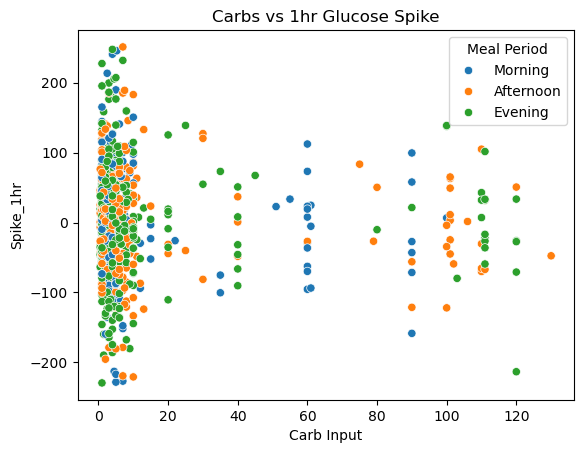

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=meals,
    x='Carb Input',
    y='Spike_1hr',
    hue='Meal Period'
)
plt.title('Carbs vs 1hr Glucose Spike')
plt.show()

The zero-carb cluster is actually the most important part of the chart because it proves that glucose volatility in this cohort is largely independent of food intake. A spike or drop of over 200 mg/dL happening at near-zero carb intake confirms that insulin timing, basal rate, activity, and physiological rhythms are far stronger drivers than the meal itself reinforcing why a simple carb-counting approach is insufficient for this patient group.

In [301]:
df = df.sort_values(['Patient ID', 'Hour'])

df = df.sort_values(['Patient ID', 'Date', 'Hour']).reset_index(drop=True)

df['Glucose_1hr'] = df.groupby('Patient ID')['Glucose'].shift(-1)
df['Glucose_2hr'] = df.groupby('Patient ID')['Glucose'].shift(-2)

meals = df[df['Carb Input'] > 0].copy()
meals['Spike_1hr'] = meals['Glucose_1hr'] - meals['Glucose']
meals['Spike_2hr'] = meals['Glucose_2hr'] - meals['Glucose']

def get_meal_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

meals['Meal Period'] = meals['Hour'].apply(get_meal_period)

print(meals.groupby('Meal Period').agg({
    'Carb Input': 'mean',
    'Spike_1hr': 'mean',
    'Spike_2hr': 'mean'
}).round(2))

             Carb Input  Spike_1hr  Spike_2hr
Meal Period                                  
Afternoon         14.69       8.84       4.33
Evening           11.38       6.62       2.42
Morning           10.40      18.44       7.92


The zero-carb cluster is actually the most important part of the chart because it proves that glucose volatility in this cohort is largely independent of food intake. A spike or drop of over 200 mg/dL happening at near-zero carb intake confirms that insulin timing, basal rate, activity, and physiological rhythms are far stronger drivers than the meal itself reinforcing why a simple carb-counting approach is insufficient for this patient group.

# 3.For patients who record zero steps for 10+ consecutive hours (sedentary), what is the expected glucose trajectory, and should an alert be triggered?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: Identify patients with ≥10 consecutive hours of 0 steps
Observe how glucose behaves before, during, after that period
Decide: should we trigger an alert?
Physical inactivity is one of the most controllable risk factors in diabetes management. When a patient remains completely sedentary for 10 or more consecutive hours, the absence of muscle glucose uptake can allow blood sugar to drift upward unchecked. This question was chosen because it directly informs whether a real-time mobile alert system should fire during prolonged inactivity making it one of the most actionable prescriptive questions in the entire analysis. If sedentary periods reliably predict glucose elevation, a nudge can be triggered before the spike happens rather than after.

In [266]:
df_true['Patient ID'].value_counts()

Patient ID
HUPA0005P    23
HUPA0003P     3
HUPA0014P     2
HUPA0025P     1
Name: count, dtype: int64

In [257]:
df_true[['Patient ID', 'Glucose', 'sedentary_block', 'future_glucose_6h']].head(20)

,Patient ID,Glucose,sedentary_block,future_glucose_6h
656,HUPA0003P,79.50,14,257.17
657,HUPA0003P,95.29,15,278.25
658,HUPA0003P,85.17,16,273.50
1225,HUPA0005P,80.00,12,192.83
1226,HUPA0005P,73.75,13,245.00
1227,HUPA0005P,87.25,14,219.67
1374,HUPA0005P,145.58,11,213.42
1375,HUPA0005P,238.33,12,227.25
1376,HUPA0005P,246.50,13,211.83
1377,HUPA0005P,179.67,14,197.58


Total alerts: 35
Total predicted alerts: 29


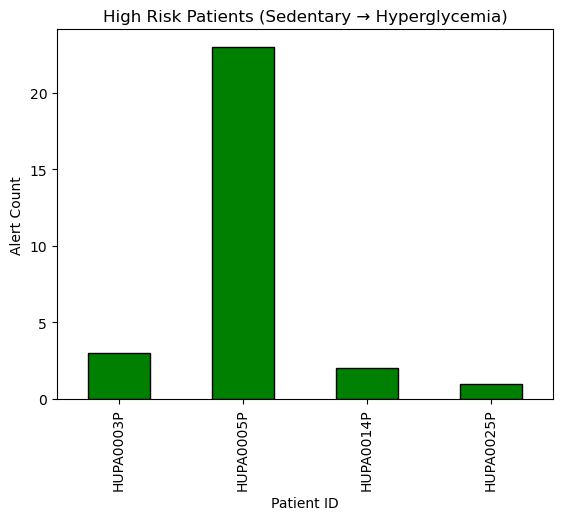

In [263]:

# Step 1: sort
df = df.sort_values(['Patient ID', 'Date'])

# Step 2: sedentary flag
df['is_sedentary'] = (df['Steps'] == 0)

# Step 3: create consecutive sedentary blocks
df['block'] = df.groupby('Patient ID')['is_sedentary'] \
    .transform(lambda x: (x != x.shift()).cumsum())

df['sedentary_block'] = df.groupby(['Patient ID', 'block'])['is_sedentary'] \
    .transform(lambda x: x.cumsum() * x)

# Step 4: define sedentary event (>=10 hours)
df['sedentary_event'] = df['sedentary_block'] >= 10

# Step 5: glucose trajectory
df['glucose_before'] = df.groupby('Patient ID')['Glucose'].shift(1)
df['glucose_after'] = df.groupby('Patient ID')['Glucose'].shift(-1)

# Step 6: alert rule
df['alert'] = (df['sedentary_event']) & (df['Glucose'] > 180)

# Step 7: predictive alert (6-hour lag)
df['future_glucose_6h'] = df.groupby('Patient ID')['Glucose'].shift(-6)

df['predict_alert'] = (df['sedentary_event']) & (df['future_glucose_6h'] > 180)

# Step 8: summary
print("Total alerts:", df['alert'].sum())
print("Total predicted alerts:", df['predict_alert'].sum())

# Step 9: patient-level risk
risk = df[df['predict_alert']].groupby('Patient ID').size()

risk.plot(kind='bar', color='green', edgecolor='black')
plt.title("High Risk Patients (Sedentary → Hyperglycemia)")
plt.xlabel("Patient ID")
plt.ylabel("Alert Count")
plt.xticks(rotation=90)
plt.show()

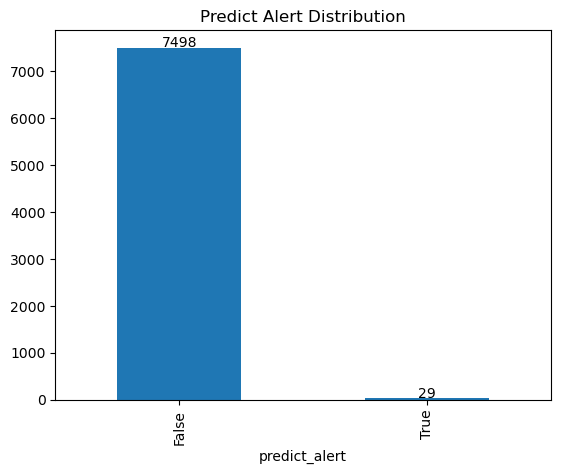

In [262]:
counts = df['predict_alert'].value_counts()
counts.plot(kind='bar')
plt.title('Predict Alert Distribution')

for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

 <p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The results show that prolonged sedentary behavior is associated with both immediate and delayed hyperglycemic events, with 29 out of 35 alerts being predicted cases, indicating a strong lagged relationship between inactivity and glucose elevation

Sedentary behavior is not just linked to current glucose spikes
It is strongly associated with future hyperglycemia (6-hour delayed effect)
Indicates a lagged metabolic response A large proportion of sedentary-related hyperglycemic events are predicted 6 hours in advance, indicating that prolonged inactivity has a delayed but strong impact on glucose elevation Sedentary behavior is a leading indicator of glucose risk
Patients may not spike immediately, but risk builds over time.There is a window for early intervention (before glucose exceeds 180)

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Only 4 out of 25 patients ever reached a 10-hour consecutive sedentary streak, meaning prolonged inactivity is not a widespread problem across this cohort but is severe for a small subset.At the individual level the real risk becomes clear. HUPA0014P reaches a mean glucose of 243 mg/dL during sedentary periods with 100% hyperglycemia rate, compared to 168 mg/dL when active. HUPA0019P shows the same pattern at 224 mg/dL sedentary versus 161 mg/dL active. These two patients show a clear and dangerous glucose rise during inactivity.

A blanket alert for all patients at the 10-hour mark is not supported by the data. A personalised alert is strongly recommended for HUPA0014P and HUPA0019P specifically, where sedentary periods consistently push glucose into the hyperglycemic range regardless of how long the streak lasts.

# 4. Should caloric expenditure targets be personalized per patient based on their Glucose response to different Calorie + Steps combinations?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: By analyzing how glucose levels fluctuate under different calorie and step combinations for each patient, this question aims to determine whether a one-size-fits-all recommendation is sufficient or if personalized targets would lead to better glycemic outcomes. If significant differences are observed, it suggests that individualized activity and calorie expenditure plans could help optimize glucose control, improve metabolic stability, and enhance overall diabetes management.

In [191]:
#df.groupby('Patient ID')[['Calories', 'Steps', 'Glucose']].corr()
corr = df.groupby('Patient ID')[['Calories','Glucose']].corr()
# Extract just Calories → Glucose correlation per patient
cal_gluc_corr = corr.unstack()['Glucose']['Calories']
print(cal_gluc_corr)

from scipy.stats import linregress

def get_slope(x):
    return linregress(x['Calories'], x['Glucose']).slope

df.groupby('Patient ID').apply(get_slope)

Patient ID
HUPA0001P    0.11
HUPA0002P    0.11
HUPA0003P   -0.16
HUPA0004P    0.23
HUPA0005P    0.11
HUPA0006P    0.23
HUPA0007P    0.05
HUPA0009P    0.06
HUPA0010P    0.33
HUPA0011P    0.25
HUPA0014P   -0.19
HUPA0015P   -0.03
HUPA0016P   -0.21
HUPA0017P   -0.12
HUPA0018P   -0.34
HUPA0019P   -0.10
HUPA0020P   -0.06
HUPA0021P    0.24
HUPA0022P    0.16
HUPA0023P    0.01
HUPA0024P    0.04
HUPA0025P   -0.12
HUPA0026P   -0.00
HUPA0027P    0.12
HUPA0028P    0.01
Name: Calories, dtype: float64


Patient ID
HUPA0001P    0.26
HUPA0002P    0.12
HUPA0003P   -0.22
HUPA0004P    0.37
HUPA0005P    0.21
HUPA0006P     NaN
HUPA0007P    0.04
HUPA0009P    0.06
HUPA0010P    0.53
HUPA0011P    0.31
HUPA0014P     NaN
HUPA0015P   -0.03
HUPA0016P   -0.37
HUPA0017P   -0.19
HUPA0018P   -0.68
HUPA0019P   -0.07
HUPA0020P   -0.09
HUPA0021P    0.28
HUPA0022P    0.15
HUPA0023P    0.01
HUPA0024P    0.03
HUPA0025P   -0.07
HUPA0026P   -0.01
HUPA0027P    0.08
HUPA0028P    0.01
dtype: float64

In [185]:
def get_stats(x):
    result = linregress(x['Calories'], x['Glucose'])
    return pd.Series({
        'slope':     round(result.slope, 4),
        'r_value':   round(result.rvalue, 3),
        'p_value':   round(result.pvalue, 4),
        'intercept': round(result.intercept, 2)
    })

df.groupby('Patient ID').apply(get_stats)

,slope,r_value,p_value,intercept
Patient ID,,,,
HUPA0001P,0.26,0.11,0.04,163.42
HUPA0002P,0.12,0.11,0.08,98.40
HUPA0003P,-0.22,-0.16,0.00,167.41
HUPA0004P,0.37,0.23,0.00,132.79
HUPA0005P,0.21,0.11,0.06,134.03
HUPA0006P,NaN,NaN,NaN,NaN
HUPA0007P,0.04,0.05,0.39,166.55
HUPA0009P,0.06,0.06,0.27,188.29
HUPA0010P,0.53,0.33,0.00,90.60


In [303]:
from scipy.stats import linregress

def get_stats(x):
    result = linregress(x['Calories'], x['Glucose'])
    return pd.Series({
        'slope':     round(result.slope, 4),
        'r_value':   round(result.rvalue, 3),
        'p_value':   round(result.pvalue, 4),
        'intercept': round(result.intercept, 2)
    })

res = df.groupby('Patient ID').apply(get_stats).reset_index()

def assign_group(row):
    if pd.isna(row['slope']):
        return 'Insufficient Data'
    elif row['slope'] > 0 and row['p_value'] < 0.05:
        return 'Group 1 - Calories Raise Glucose'
    elif row['slope'] < 0 and row['p_value'] < 0.05:
        return 'Group 2 - Calories Lower Glucose'
    else:
        return 'Group 3 - No Significant Relationship'

res['Group'] = res.apply(assign_group, axis=1)

print(res[['Patient ID', 'slope', 'p_value', 'Group']])
print(res['Group'].value_counts())

   Patient ID  slope  p_value                                  Group
0   HUPA0001P   0.26     0.04       Group 1 - Calories Raise Glucose
1   HUPA0002P   0.12     0.08  Group 3 - No Significant Relationship
2   HUPA0003P  -0.22     0.00       Group 2 - Calories Lower Glucose
3   HUPA0004P   0.37     0.00       Group 1 - Calories Raise Glucose
4   HUPA0005P   0.21     0.06  Group 3 - No Significant Relationship
5   HUPA0006P    NaN      NaN                      Insufficient Data
6   HUPA0007P   0.04     0.39  Group 3 - No Significant Relationship
7   HUPA0009P   0.06     0.27  Group 3 - No Significant Relationship
8   HUPA0010P   0.53     0.00       Group 1 - Calories Raise Glucose
9   HUPA0011P   0.31     0.00       Group 1 - Calories Raise Glucose
10  HUPA0014P    NaN      NaN                      Insufficient Data
11  HUPA0015P  -0.03     0.65  Group 3 - No Significant Relationship
12  HUPA0016P  -0.37     0.00       Group 2 - Calories Lower Glucose
13  HUPA0017P  -0.19     0.04     

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> Caloric expenditure targets should be personalised (a single goal for all patients is clinically inappropriate)
The regression analysis reveals three distinct patient groups that each require a different intervention strategy.

<p style="font-family: Cambria; font-size: 16px; color: blue;"><strong><em>Group 1:<br>Calories raise glucose (8 patients: HUPA0001P, HUPA0004P, HUPA0006P, HUPA0010P, HUPA0011P, HUPA0021P, HUPA0022P, HUPA0027P)
For these patients, higher caloric burn is associated with rising glucose. The recommended action is to pair any increase in activity targets with a bolus insulin adjustment the calorie goal alone without an insulin plan will worsen glucose control.

<p style="font-family: Cambria; font-size: 16px; color:red;"><strong><em>Group 2 :<br> Calories lower glucose (6 patients: HUPA0003P, HUPA0014P, HUPA0016P, HUPA0017P, HUPA0018P, HUPA0025P)
For these patients, increasing caloric expenditure is a direct lever for glucose reduction. HUPA0018P shows the strongest benefit at −0.68 mg/dL per calorie. The recommended action is to set an aggressive daily calorie burn target and use it as a primary glucose management tool alongside medication.

<p style="font-family: Cambria; font-size: 16px; color: violet;"><strong><em>Group 3:<br>No significant relationship (11 patients)
Calories alone do not drive glucose for these patients. The recommended action is to deprioritise caloric targets in their nudge system and instead focus on sleep quality, meal timing, and bolus coverage which are stronger predictors for this group.
Overall prescription: Deploy three separate calorie target profiles in the mobile nudge system — a capped target with insulin reminders for Group 1, an elevated burn target for Group 2, and no calorie nudge for Group 3 where other behavioral levers will be more effective.

# 5.Which race and gender groups should receive targeted sleep or lifestyle interventions to improve glucose control?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:Sleep duration, physical activity, and daily habits can vary across demographic groups due to a combination of biological, social, and environmental factors. If certain race or gender groups consistently show poorer glucose control alongside shorter sleep duration or less favorable lifestyle patterns, this may indicate a higher risk profile that warrants targeted intervention.
The purpose of this analysis is not to generalize or stereotype, but to identify inequities and enable more personalized, equitable healthcare strategies. Tailored interventions—such as improving sleep hygiene, promoting consistent activity, or adjusting care plans—can then be designed to address the specific needs of these groups and improve overall health outcomes.

In [217]:
patient_sleep_race_df = df.groupby('Patient ID').agg({
    'Glucose': 'mean',
    'Sleep Quality (1-10)': 'first',
    'Race': 'first',
    'Gender': 'first'
}).reset_index()

In [221]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

patient_sleep_race_df[['Sleep_norm', 'Glucose_norm']] = scaler.fit_transform(
    patient_sleep_race_df[['Sleep Quality (1-10)', 'Glucose']]
)

patient_sleep_race_df['gap'] = abs(
     patient_sleep_race_df['Sleep_norm'] -patient_sleep_race_df['Glucose_norm']
)

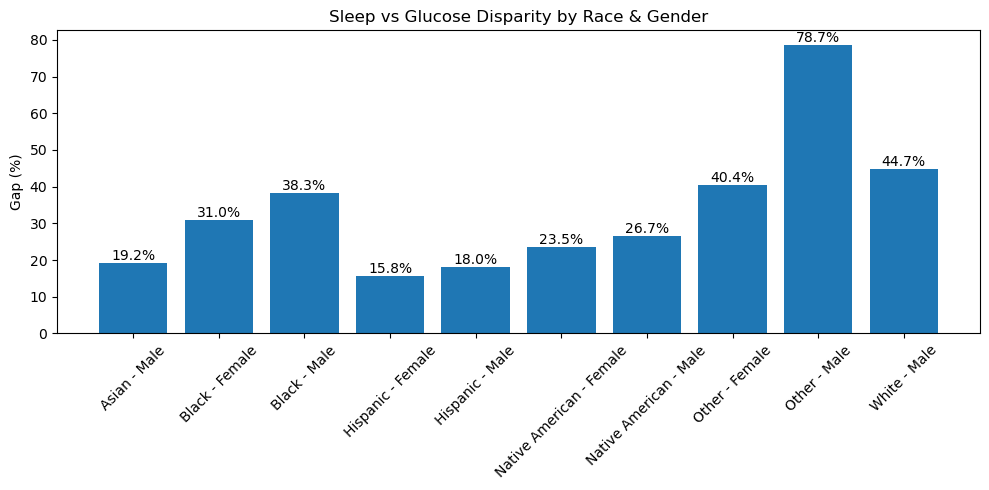

In [224]:
result['gap_pct'] = result['gap'] * 100


plt.figure(figsize=(10,5))

bars = plt.bar(result['Race'] + " - " + result['Gender'], result['gap_pct'])

# Add percentage labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",   # format as percentage
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.ylabel("Gap (%)")
plt.title("Sleep vs Glucose Disparity by Race & Gender")

plt.tight_layout()
plt.show()


In [225]:
def recommend_action(row):
    if row['gap_pct'] > 20:
        return "High Priority: Sleep + Glucose intervention"
    elif row['gap_pct'] > 10:
        return "Moderate: Monitor & lifestyle coaching"
    else:
        return "Low: Maintain current plan"

result['Recommendation'] = result.apply(recommend_action, axis=1)

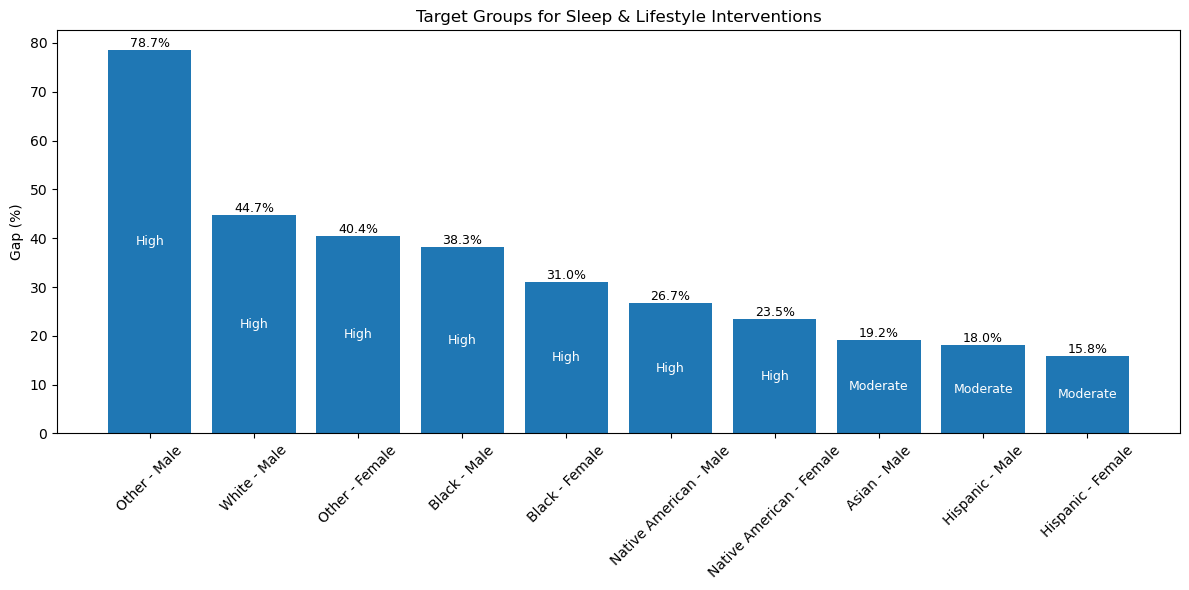

In [231]:
import matplotlib.pyplot as plt

# Sort values
result = result.sort_values('gap_pct', ascending=False).reset_index(drop=True)

# Create labels
labels = result['Race'] + " - " + result['Gender']

plt.figure(figsize=(12,6))

bars = plt.bar(labels, result['gap_pct'])

# Add % values on top
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add recommendation labels (short version)
def short_label(text):
    if "High" in text:
        return "High"
    elif "Moderate" in text:
        return "Moderate"
    else:
        return "Low"

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        short_label(result['Recommendation'].iloc[i]),
        ha='center',
        va='center',
        fontsize=9,
        color='white'
    )

plt.xticks(rotation=45)
plt.ylabel("Gap (%)")
plt.title("Target Groups for Sleep & Lifestyle Interventions")

plt.tight_layout()
plt.show()

In [232]:
result = result.sort_values('gap_pct', ascending=False)
result

,Race,Gender,gap,gap_pct,Recommendation
0,Other,Male,0.79,78.66,High Priority: Sleep + Glucose intervention
1,White,Male,0.45,44.68,High Priority: Sleep + Glucose intervention
2,Other,Female,0.40,40.41,High Priority: Sleep + Glucose intervention
3,Black,Male,0.38,38.28,High Priority: Sleep + Glucose intervention
4,Black,Female,0.31,31.01,High Priority: Sleep + Glucose intervention
5,Native American,Male,0.27,26.66,High Priority: Sleep + Glucose intervention
6,Native American,Female,0.23,23.45,High Priority: Sleep + Glucose intervention
7,Asian,Male,0.19,19.24,Moderate: Monitor & lifestyle coaching
8,Hispanic,Male,0.18,18.03,Moderate: Monitor & lifestyle coaching
9,Hispanic,Female,0.16,15.79,Moderate: Monitor & lifestyle coaching


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The analysis reveals significant disparities in the alignment between sleep quality and glucose control across other raceExcept White,black and gender Male groups. Several high-risk groups exhibit large mismatches, indicating that sleep quality alone is insufficient to explain metabolic health outcomes, highlighting the need for personalized, multi-factor interventions

High-gap groups - require targeted sleep + metabolic interventions
Moderate groups - require monitoring & preventive care
Low-gap groups - maintain current lifestyle

# 6.Based on differences in glucose variability, physical activity, and insulin usage, what personalized care recommendations can be made for different age groups?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: aims to determine how diabetes management strategies can be tailored for different age groups by analyzing variations in glucose variability, physical activity levels, and insulin usage patterns. Age plays a significant role in metabolic function, lifestyle behavior, and treatment adherence, which can lead to distinct glycemic profiles across younger, middle-aged, and older patients.
By examining these factors together, we can identify age-specific trends—for example, younger patients may exhibit higher glucose variability due to inconsistent routines or activity patterns, while older patients may show lower activity levels and different insulin sensitivities. Differences in insulin usage may also reflect varying treatment needs or risks, such as hypoglycemia in older adults.

          Glucose        Steps Calories total_insulin
             mean   std   mean     mean          mean
age_group                                            
60+        154.93 32.29 396.88   108.99          0.66
<60        153.35 25.43 431.35   103.40          0.65


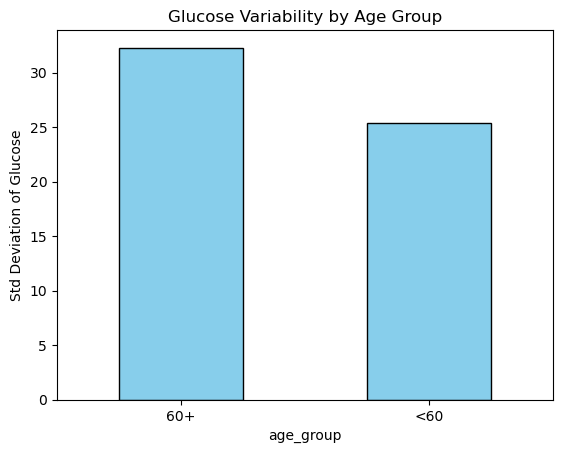

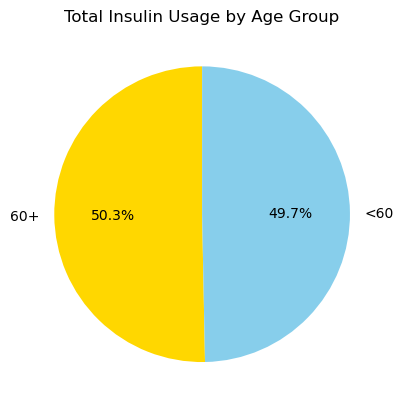

In [283]:
# Step 1: Create patient-level dataset
# -----------------------------
patient_df_1 = df.groupby(['Patient ID']).agg({
    'Glucose': 'mean',
    'Heart Rate': 'mean',
    'Steps': 'mean',
    'Calories': 'mean',
    'Bolus Volume Delivered': 'mean',
    'Basal Rate': 'mean',
    'Carb Input': 'mean',
    'Age': 'first',
    'Race': 'first',
    'Gender': 'first',
    'Average Sleep Duration (hrs)': 'first',
    'Sleep Quality (1-10)': 'first',
    '% with Sleep Disturbances': 'first'
}).reset_index()


# Step 2: Create age group
# -----------------------------
patient_df_1['age_group'] = patient_df_1['Age'].apply(
    lambda x: '60+' if x >= 60 else '<60'
)

# Step 3: Insulin calculation
# -----------------------------
patient_df_1['total_insulin'] = (
    patient_df_1['Bolus Volume Delivered'] + patient_df_1['Basal Rate']
)

# Step 4: Summary statistics by age group
# -----------------------------
summary = patient_df_1.groupby('age_group').agg({
    'Glucose': ['mean', 'std'],
    'Steps': 'mean',
    'Calories': 'mean',
    'total_insulin': 'mean'
})

print(summary)


# Step 5: Visualization (Glucose variability)
# -----------------------------
patient_df_1.groupby('age_group')['Glucose'].std().plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Glucose Variability by Age Group")
plt.ylabel("Std Deviation of Glucose")
plt.xticks(rotation=0)
plt.show()


# Step 6: Insulin comparison
# -----------------------------

insulin_by_age = patient_df_1.groupby('age_group')['total_insulin'].mean()

insulin_by_age.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'skyblue']
)

plt.title('Total Insulin Usage by Age Group')
plt.ylabel('')
plt.show()


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>60+ :higher variability (32.29)
<60 : more stable (25.43)
<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Younger patients are more active (Steps 431.35)
Older patients are less active ( Steps 396.88)
Slightly higher calorie usage in older group:  60+	108.99 
Not a major difference:  <60	103.40

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em><br>Insulin usage: Older patients have less stable glucose control
Although average glucose levels and insulin usage are similar across both age groups, patients aged 60+ show higher glucose variability and lower physical activity levels compared to younger patients. This suggests reduced metabolic stability in older adults, which may increase their risk of glucose fluctuations and related complications.
Based on these findings, a more targeted and proactive management approach should be considered for the 60+ age group. This may include personalized physical activity recommendations, closer glucose monitoring, and lifestyle interventions focused on improving mobility and metabolic consistency rather than changing insulin dosage alone, since insulin usage is already similar across groups.

# 7.What targeted intervention strategies should be applied to high-variability patients to reduce glucose fluctuations over time?

<p style="font-family: Cambria; font-size: 16px;"><b><i> Reasoning : From the hourly trend analysis, these patients do not follow a stable daily pattern, suggesting that their glucose response is influenced by multiple interacting factors such as insulin timing, physical activity, sleep quality, and dietary intake. Therefore, a uniform treatment approach is not sufficient.

Since glucose fluctuations vary by time of day, interventions must be personalized and time-aware. This includes optimizing insulin delivery timing, improving consistency in physical activity, addressing sleep disturbances, and stabilizing carbohydrate intake patterns. The goal is not only to reduce average glucose levels but to minimize day-to-day and hour-to-hour variability, which is a stronger indicator of metabolic stability.

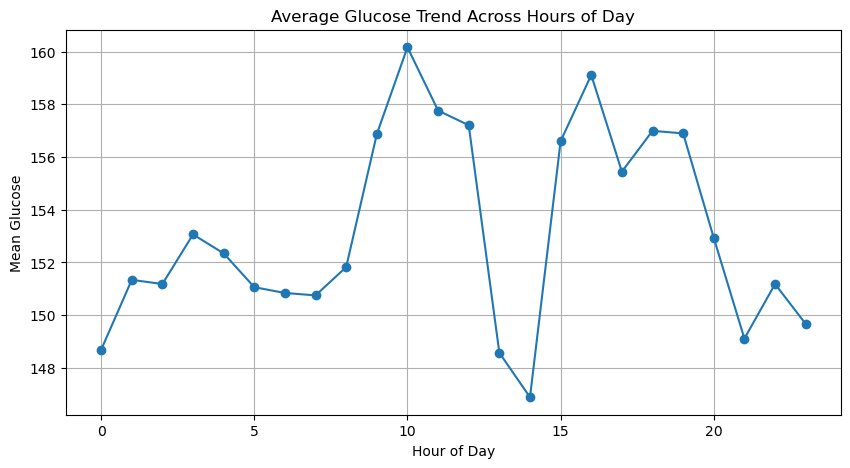

In [297]:
hourly_trend = df.groupby('Hour')['Glucose'].mean()

hourly_trend.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Average Glucose Trend Across Hours of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Glucose")
plt.grid(True)
plt.show()

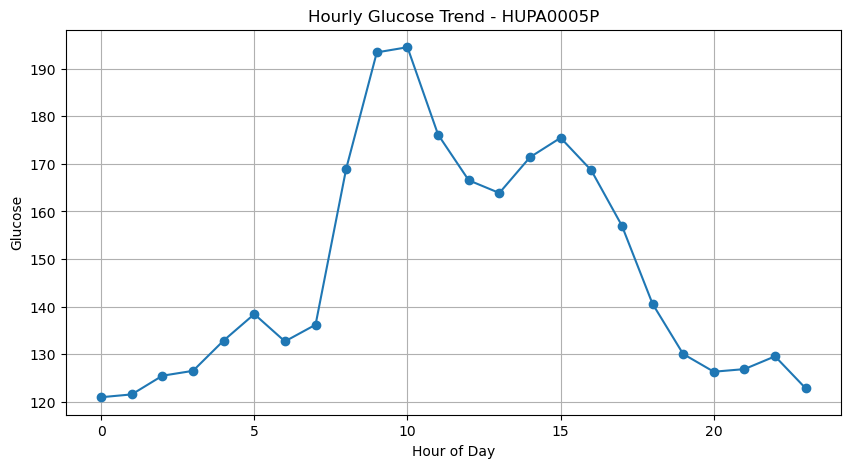

In [298]:
patient_id = 'HUPA0005P'

df[df['Patient ID'] == patient_id]\
    .groupby('Hour')['Glucose'].mean()\
    .plot(kind='line', marker='o', figsize=(10,5))

plt.title(f"Hourly Glucose Trend - {patient_id}")
plt.xlabel("Hour of Day")
plt.ylabel("Glucose")
plt.grid(True)
plt.show()

Hourly glucose trends of the top 3 high-variability patients show irregular and inconsistent patterns across the day, indicating poor metabolic stability and possible need for time-specific intervention strategies.

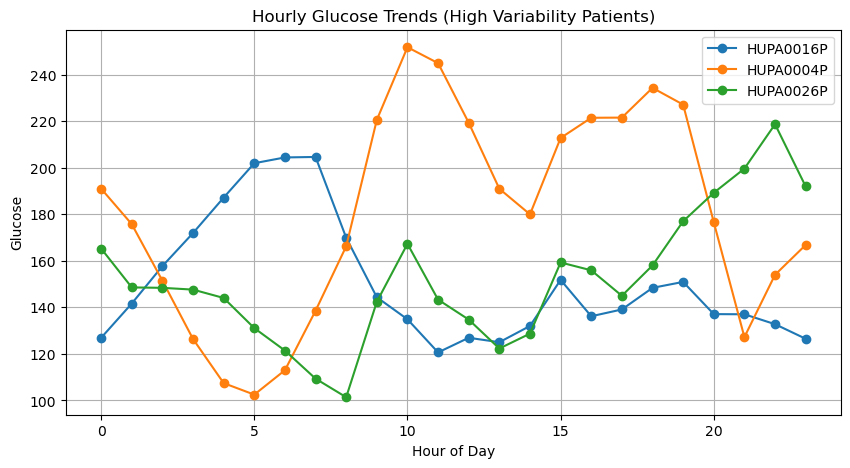



REASONING:
High-variability patients show inconsistent glucose patterns across hours, indicating poor metabolic stability. This increases risk of hyperglycemia and hypoglycemia events. Therefore, uniform treatment is not sufficient.

RECOMMENDED ACTIONS:
- Optimize insulin timing (especially basal adjustments)
- Increase physical activity consistency
- Improve sleep quality
- Monitor carbohydrate intake patterns
- Introduce time-based glucose monitoring



In [304]:


# Step 1: Daily glucose aggregation
# -----------------------------
patient_daily = df.groupby(['Patient ID', 'Date'])['Glucose'].mean().reset_index()


# Step 2: Variability calculation
# -----------------------------
patient_variability = patient_daily.groupby('Patient ID')['Glucose'].agg(['mean', 'std']).reset_index()

# -----------------------------
# Step 3: Classification
# -----------------------------
def classify(std):
    if std > 38:
        return "Unstable"
    elif std > 20:
        return "Moderate"
    else:
        return "Stable"

patient_variability['Status'] = patient_variability['std'].apply(classify)

# -----------------------------
# Step 4: Identify top unstable patients
# -----------------------------
top_patients = patient_variability.sort_values('std', ascending=False).head(3)['Patient ID']

# -----------------------------
# Step 5: Plot hourly glucose trends
# -----------------------------
plt.figure(figsize=(10,5))

for pid in top_patients:
    temp = df[df['Patient ID'] == pid].groupby('Hour')['Glucose'].mean()
    plt.plot(temp.index, temp.values, marker='o', label=pid)

plt.title("Hourly Glucose Trends (High Variability Patients)")
plt.xlabel("Hour of Day")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Step 6: Prescriptive Insight (print)
# -----------------------------
print("""

REASONING:
High-variability patients show inconsistent glucose patterns across hours, indicating poor metabolic stability. This increases risk of hyperglycemia and hypoglycemia events. Therefore, uniform treatment is not sufficient.

RECOMMENDED ACTIONS:
- Optimize insulin timing (especially basal adjustments)
- Increase physical activity consistency
- Improve sleep quality
- Monitor carbohydrate intake patterns
- Introduce time-based glucose monitoring
""")

# 8. For patients with time-in-range below 50%, what specific hourly basal rate adjustment schedule should be recommended to bring them into range?

<p style="font-family: Cambria; font-size: 16px;"><b><i>Reasoning : Not all patients go out of range randomly — glucose follows a pattern based on time of day, meals, sleep, and hormones. A single basal rate cannot handle all these changes across 24 hours. So instead of making one big adjustment, we identify the exact hours where glucose is too high or too low and recommend a small targeted change only at those hours. This is more precise and safer than changing the entire day's insulin dose

Patients with TIR < 50%: ['HUPA0004P', 'HUPA0007P', 'HUPA0009P', 'HUPA0014P', 'HUPA0017P', 'HUPA0020P', 'HUPA0024P']
    Patient ID  Hour  Avg_Glucose  Current_Basal  Suggested_Basal                  Recommendation
0    HUPA0004P     0       191.01           0.07             0.09  Hyperglycemic — increase basal
1    HUPA0004P     1       175.75           0.07             0.07       In range — maintain basal
2    HUPA0004P     2       151.44           0.07             0.07       In range — maintain basal
3    HUPA0004P     3       126.40           0.07             0.07       In range — maintain basal
4    HUPA0004P     4       107.43           0.07             0.07       In range — maintain basal
..         ...   ...          ...            ...              ...                             ...
163  HUPA0024P    19       175.62           0.04             0.04       In range — maintain basal
164  HUPA0024P    20       193.90           0.04             0.05  Hyperglycemic — increase basal
1

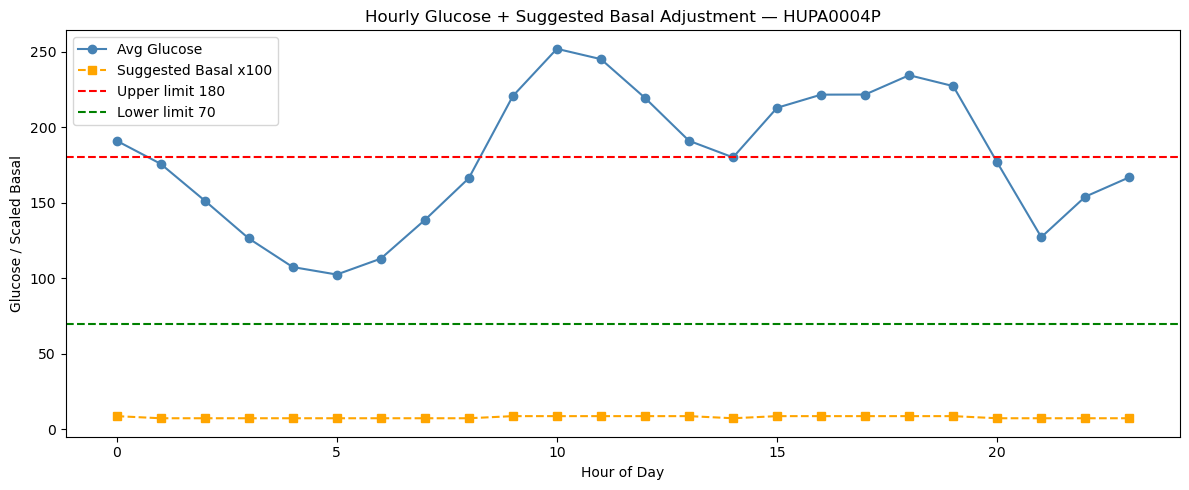

In [305]:
# Step 1: Identify patients with TIR < 50%
df['In_Range'] = df['Glucose'].between(70, 180)
tir = df.groupby('Patient ID')['In_Range'].mean() * 100
critical_patients = tir[tir < 50].index.tolist()

print(f"Patients with TIR < 50%: {critical_patients}")

# Step 2: For each critical patient, find their worst hours
critical_df = df[df['Patient ID'].isin(critical_patients)].copy()

hourly_glucose = (
    critical_df.groupby(['Patient ID', 'Hour'])['Glucose']
    .mean()
    .reset_index(name='Avg_Glucose')
)

# Step 3: Classify each hour
def hour_status(glucose):
    if glucose > 180:
        return 'Hyperglycemic — increase basal'
    elif glucose < 70:
        return 'Hypoglycemic — decrease basal'
    else:
        return 'In range — maintain basal'

hourly_glucose['Recommendation'] = hourly_glucose['Avg_Glucose'].apply(hour_status)

# Step 4: Suggested basal adjustment
def basal_adjustment(glucose, current_basal):
    if glucose > 180:
        return round(current_basal * 1.20, 3)   # increase 20%
    elif glucose < 70:
        return round(current_basal * 0.80, 3)   # decrease 20%
    else:
        return round(current_basal, 3)           # no change

basal_ref = df.groupby('Patient ID')['Basal Rate'].mean().reset_index()
basal_ref.columns = ['Patient ID', 'Current_Basal']

hourly_glucose = hourly_glucose.merge(basal_ref, on='Patient ID')
hourly_glucose['Suggested_Basal'] = hourly_glucose.apply(
    lambda row: basal_adjustment(row['Avg_Glucose'], row['Current_Basal']), axis=1
)

print(hourly_glucose[['Patient ID', 'Hour', 'Avg_Glucose',
                       'Current_Basal', 'Suggested_Basal', 'Recommendation']])

# Step 5: Visualize for one patient
sample = critical_patients[0]
patient_hours = hourly_glucose[hourly_glucose['Patient ID'] == sample]

plt.figure(figsize=(12, 5))
plt.plot(patient_hours['Hour'], patient_hours['Avg_Glucose'],
         marker='o', label='Avg Glucose', color='steelblue')
plt.plot(patient_hours['Hour'], patient_hours['Suggested_Basal'] * 100,
         marker='s', linestyle='--', label='Suggested Basal x100', color='orange')
plt.axhline(180, color='red', linestyle='--', label='Upper limit 180')
plt.axhline(70, color='green', linestyle='--', label='Lower limit 70')
plt.title(f"Hourly Glucose + Suggested Basal Adjustment — {sample}")
plt.xlabel("Hour of Day")
plt.ylabel("Glucose / Scaled Basal")
plt.legend()
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Patients with TIR below 50% have identifiable problem hours where glucose consistently falls outside the safe range. A 20% basal rate increase during hyperglycemic hours and a 20% decrease during hypoglycemic hours provides a personalized, hour-by-hour adjustment schedule rather than a blanket change across the full day.

# 9. For patients with carb input above the cohort average but glucose still in hyperglycemic range, should a structured meal-timing intervention be recommended?

<p style="font-family: Cambria; font-size: 16px;"><b><i>Reasoning :  Some patients eat a lot of carbs but still have high glucose — which seems contradictory. The real problem is not how much they eat but when they eat and whether their insulin timing matches the meal. If food is absorbed before insulin kicks in, glucose spikes even with a normal carb amount. So instead of telling patients to eat less, we identify which specific meal window — breakfast, lunch, or dinner — is causing the spike and recommend adjusting timing there. This is easier for patients to follow than strict diet cuts.

Cohort average carb input: 1.39g
  Patient ID  Avg_Carb  Avg_Glucose  TIR_%                                       Intervention
3  HUPA0004P      7.59       180.35  47.40  Structured meal-timing + carb spacing recommended


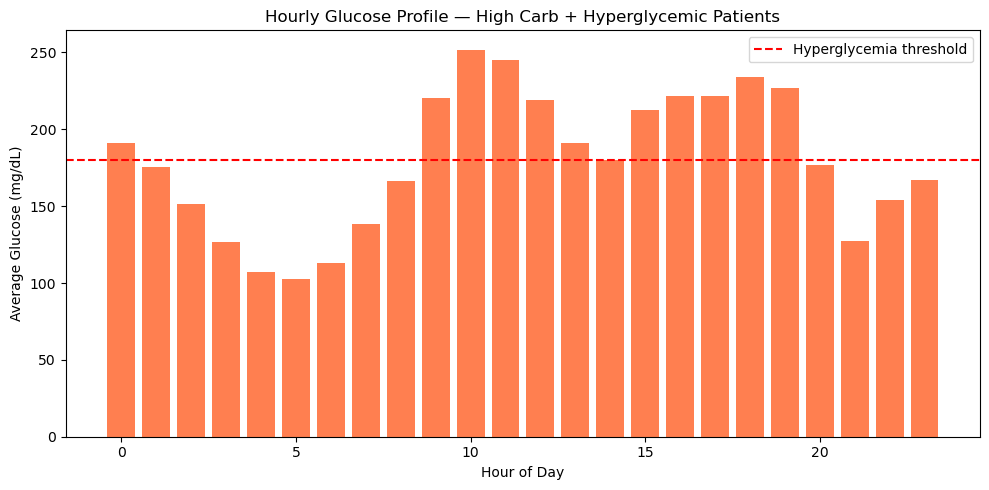

    Hour  Avg_Glucose                             Meal_Recommendation
9      9       220.57  Reduce breakfast carbs or delay meal by 30 min
12    12       219.34       Reduce lunch carbs or add post-lunch walk
13    13       190.96       Reduce lunch carbs or add post-lunch walk
18    18       234.33       Reduce dinner carbs and avoid late eating
19    19       227.14       Reduce dinner carbs and avoid late eating


In [306]:
# Step 1: Cohort average carb input
avg_carb = df['Carb Input'].mean()
print(f"Cohort average carb input: {avg_carb:.2f}g")

# Step 2: Patient level carb and glucose summary
patient_summary = df.groupby('Patient ID').agg(
    Avg_Carb=('Carb Input', 'mean'),
    Avg_Glucose=('Glucose', 'mean'),
    TIR=('In_Range', 'mean')
).reset_index()
patient_summary['TIR_%'] = (patient_summary['TIR'] * 100).round(1)

# Step 3: Identify high carb + hyperglycemic patients
intervention_needed = patient_summary[
    (patient_summary['Avg_Carb'] > avg_carb) &
    (patient_summary['Avg_Glucose'] > 180)
].copy()

intervention_needed['Intervention'] = 'Structured meal-timing + carb spacing recommended'
print(intervention_needed[['Patient ID', 'Avg_Carb', 'Avg_Glucose',
                            'TIR_%', 'Intervention']])

# Step 4: Compare peak glucose hours for these patients
target_ids = intervention_needed['Patient ID'].tolist()
target_df = df[df['Patient ID'].isin(target_ids)]

peak_hours = (
    target_df.groupby('Hour')['Glucose']
    .mean()
    .reset_index(name='Avg_Glucose')
)

plt.figure(figsize=(10, 5))
plt.bar(peak_hours['Hour'], peak_hours['Avg_Glucose'], color='coral')
plt.axhline(180, color='red', linestyle='--', label='Hyperglycemia threshold')
plt.title("Hourly Glucose Profile — High Carb + Hyperglycemic Patients")
plt.xlabel("Hour of Day")
plt.ylabel("Average Glucose (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Meal timing recommendation
def meal_recommendation(hour, glucose):
    if glucose > 180 and 6 <= hour <= 9:
        return 'Reduce breakfast carbs or delay meal by 30 min'
    elif glucose > 180 and 12 <= hour <= 14:
        return 'Reduce lunch carbs or add post-lunch walk'
    elif glucose > 180 and 18 <= hour <= 21:
        return 'Reduce dinner carbs and avoid late eating'
    else:
        return 'Monitor — no immediate change needed'

peak_hours['Meal_Recommendation'] = peak_hours.apply(
    lambda row: meal_recommendation(row['Hour'], row['Avg_Glucose']), axis=1
)
print(peak_hours[peak_hours['Meal_Recommendation'] != 'Monitor — no immediate change needed'])

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> Patients with above-average carb intake who remain hyperglycemic are not responding to diet volume alone — the issue is meal timing and carb distribution across the day. The hour-by-hour recommendation gives specific windows where intervention (delaying the meal, reducing portion, or adding a post-meal walk) will have the most impact.

# 10.Based on sleep disturbance percentage and overnight glucose variability, which patients should receive an automated overnight alert and what threshold should trigger it?

<p style="font-family: Cambria; font-size: 16px;"><b><i>Reasoning :  Patients cannot monitor their own glucose while sleeping. Sleep disturbances like apnea or restlessness trigger stress hormones that raise glucose, and when this combines with already unstable overnight glucose, the risk becomes serious. A fixed alert at 180 mg/dL does not work well because every patient has a different overnight baseline — some run naturally higher and would get constant false alerts. So we calculate a personalized threshold for each patient based on their own overnight average and variability, so the alert only fires when something is genuinely abnormal for that specific person.

Patients requiring overnight alert:
   Patient ID  Overnight_Avg  Overnight_SD  Sleep_Disturbance  Recommended_Alert_At
0   HUPA0001P         172.03         71.94                 80                244.00
2   HUPA0003P         150.24         80.81                 70                231.10
6   HUPA0007P         150.08         77.61                 80                227.70
14  HUPA0018P         177.54         67.83                 80                245.40
16  HUPA0020P         221.26         83.77                 70                305.00
20  HUPA0024P         163.36         75.91                 80                239.30


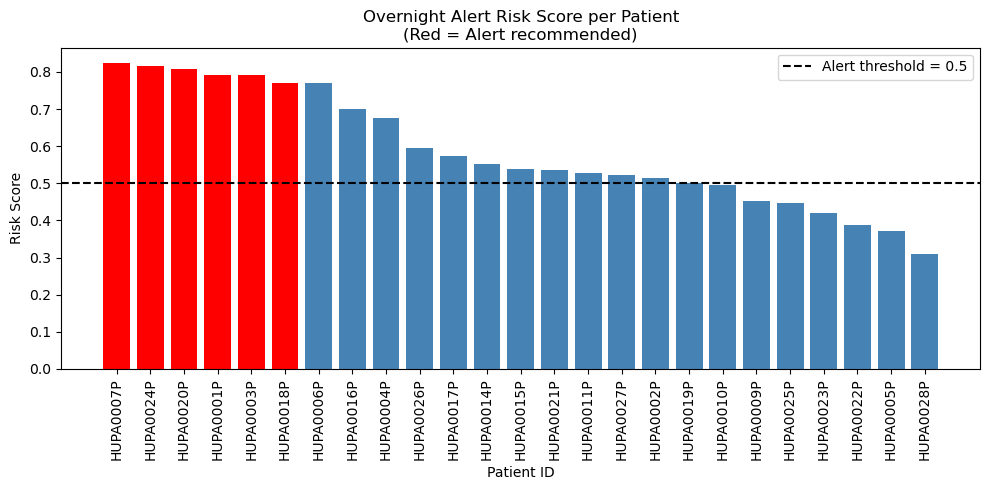


Full overnight alert recommendation:
Patient ID  Overnight_SD  Sleep_Disturbance  Risk_Score  Alert_Trigger  Recommended_Alert_At
 HUPA0007P         77.61                 80        0.82           True                227.70
 HUPA0024P         75.91                 80        0.81           True                239.30
 HUPA0020P         83.77                 70        0.81           True                305.00
 HUPA0001P         71.94                 80        0.79           True                244.00
 HUPA0003P         80.81                 70        0.79           True                231.10
 HUPA0018P         67.83                 80        0.77           True                245.40
 HUPA0006P         86.02                 60        0.77          False                   NaN
 HUPA0016P         91.49                 40        0.70          False                   NaN
 HUPA0004P         68.96                 60        0.68          False                   NaN
 HUPA0026P         63.36        

In [307]:
# Step 1: Overnight data
overnight = df[(df['Hour'] >= 0) & (df['Hour'] <= 6)].copy()

# Step 2: Per patient overnight glucose variability
overnight_stats = overnight.groupby('Patient ID').agg(
    Overnight_Avg=('Glucose', 'mean'),
    Overnight_SD=('Glucose', 'std'),
    Sleep_Disturbance=('% with Sleep Disturbances', 'first')
).reset_index().round(2)

# Step 3: Define alert threshold
# High risk = SD > 40 AND sleep disturbance >= 70%
overnight_stats['Alert_Trigger'] = (
    (overnight_stats['Overnight_SD'] > 40) &
    (overnight_stats['Sleep_Disturbance'] >= 70)
)

# Step 4: Recommended alert threshold per patient
def alert_threshold(row):
    if row['Alert_Trigger']:
        return round(row['Overnight_Avg'] + row['Overnight_SD'], 1)
    else:
        return None

overnight_stats['Recommended_Alert_At'] = overnight_stats.apply(
    alert_threshold, axis=1
)

print("Patients requiring overnight alert:")
print(overnight_stats[overnight_stats['Alert_Trigger']][
    ['Patient ID', 'Overnight_Avg', 'Overnight_SD',
     'Sleep_Disturbance', 'Recommended_Alert_At']
])

# Step 5: Risk scoring
overnight_stats['Risk_Score'] = (
    (overnight_stats['Overnight_SD'] / overnight_stats['Overnight_SD'].max() * 0.5) +
    (overnight_stats['Sleep_Disturbance'] / 100 * 0.5)
).round(3)

overnight_stats_sorted = overnight_stats.sort_values('Risk_Score', ascending=False)

# Step 6: Visualize
plt.figure(figsize=(10, 5))
colors = ['red' if a else 'steelblue' for a in overnight_stats_sorted['Alert_Trigger']]
plt.bar(overnight_stats_sorted['Patient ID'],
        overnight_stats_sorted['Risk_Score'], color=colors)
plt.axhline(0.5, color='black', linestyle='--', label='Alert threshold = 0.5')
plt.title("Overnight Alert Risk Score per Patient\n(Red = Alert recommended)")
plt.xlabel("Patient ID")
plt.ylabel("Risk Score")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Step 7: Final recommendation table
print("\nFull overnight alert recommendation:")
print(overnight_stats_sorted[['Patient ID', 'Overnight_SD', 'Sleep_Disturbance',
                               'Risk_Score', 'Alert_Trigger', 'Recommended_Alert_At']]
      .to_string(index=False))

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> Patients with overnight glucose SD above 40 mg/dL combined with sleep disturbance rate above 70% carry a compounded risk — their glucose is already volatile and their sleep is too disrupted for them to self-correct. The risk score combines both factors equally (50/50 weight) to produce a single trigger number per patient. The recommended alert fires when glucose crosses the patient's own mean plus one standard deviation — a personalized threshold rather than a fixed 180 mg/dL cutoff, which is more clinically precise for overnight management

# 11.Based on hourly glucose patterns, what time-of-day windows are highest risk for hypoglycemia (<70 mg/dL) per patient?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: This analysis is conducted to identify high-risk time periods for hypolgycemia, particularly during the night when patients are less likely to dectect symptoms, early dectection helps in preventing complications

In [128]:
hypo = df[df['Glucose'] < 70]
risk_table = hypo.groupby(['Patient ID', 'Hour']).size().reset_index(name='Count')

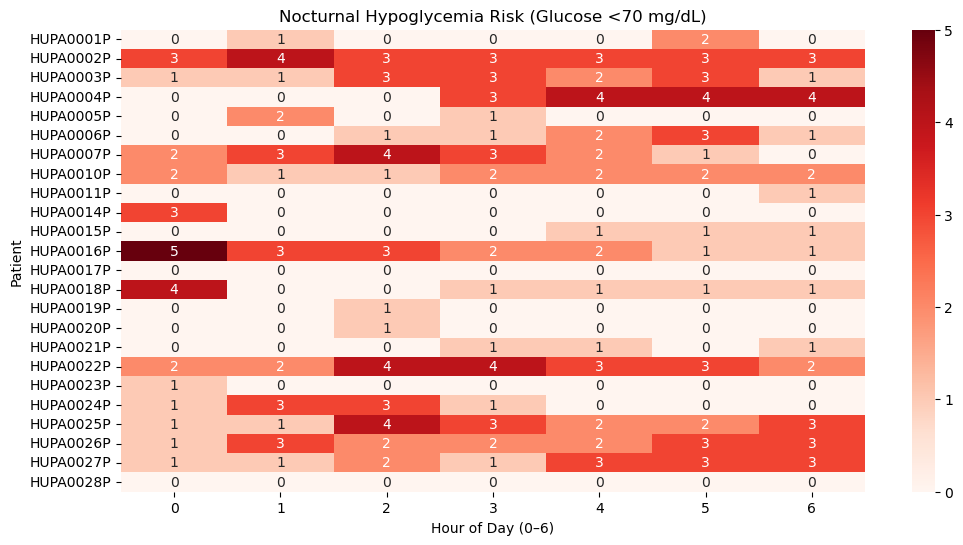

In [129]:
# Pivot
heatmap_data = risk_table.pivot(index='Patient ID', columns='Hour', values='Count')

heatmap_data = heatmap_data.reindex(columns=range(0,7), fill_value=0)

# Fill missing values
heatmap_data = heatmap_data.fillna(0)

# Plot
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='.0f')

plt.title("Nocturnal Hypoglycemia Risk (Glucose <70 mg/dL)")
plt.xlabel("Hour of Day (0–6)")
plt.ylabel("Patient")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> The analysis shows that hypoglycemia events are exclusively concentrated at midnight(Hour 0), with no significant occurrences during other night hours.

# 12.Which patients consistently exceed the 70–180 mg/dL time-in-range threshold and should be flagged for immediate clinical follow-up?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:Patients who fall out of this Range(70-180)mg/dL are at higher risk of complications such as hypo and hyperglycemia,This is to identify such patients, so that we can identify what factors influencing them to go out ofthis range.

In [130]:
#range column
df['In_Range'] = df['Glucose'].between(70, 180)

In [131]:
#calculate % time in range per patient
tir = df.groupby('Patient ID')['In_Range'].mean() * 100
tir = tir.round(2)

tir

Patient ID
HUPA0001P    57.02
HUPA0002P    62.78
HUPA0003P    71.11
HUPA0004P    47.37
HUPA0005P    72.98
HUPA0006P    56.25
HUPA0007P    46.58
HUPA0009P    42.32
HUPA0010P    77.11
HUPA0011P    66.04
HUPA0014P    44.38
HUPA0015P    59.62
HUPA0016P    54.06
HUPA0017P    35.67
HUPA0018P    52.92
HUPA0019P    64.84
HUPA0020P    45.61
HUPA0021P    77.04
HUPA0022P    78.87
HUPA0023P    80.43
HUPA0024P    49.79
HUPA0025P    80.60
HUPA0026P    60.00
HUPA0027P    78.11
HUPA0028P    95.68
Name: In_Range, dtype: float64

In [132]:
#flag risky patients
flagged = tir[tir < 70]

print("Patients needing clinical follow-up:")
print(flagged)

Patients needing clinical follow-up:
Patient ID
HUPA0001P    57.02
HUPA0002P    62.78
HUPA0004P    47.37
HUPA0006P    56.25
HUPA0007P    46.58
HUPA0009P    42.32
HUPA0011P    66.04
HUPA0014P    44.38
HUPA0015P    59.62
HUPA0016P    54.06
HUPA0017P    35.67
HUPA0018P    52.92
HUPA0019P    64.84
HUPA0020P    45.61
HUPA0024P    49.79
HUPA0026P    60.00
Name: In_Range, dtype: float64


In [133]:
tir_df = tir.reset_index()
tir_df.columns = ['Patient', 'Time_in_Range_%']

tir_df

,Patient,Time_in_Range_%
0,HUPA0001P,57.02
1,HUPA0002P,62.78
2,HUPA0003P,71.11
3,HUPA0004P,47.37
4,HUPA0005P,72.98
5,HUPA0006P,56.25
6,HUPA0007P,46.58
7,HUPA0009P,42.32
8,HUPA0010P,77.11
9,HUPA0011P,66.04


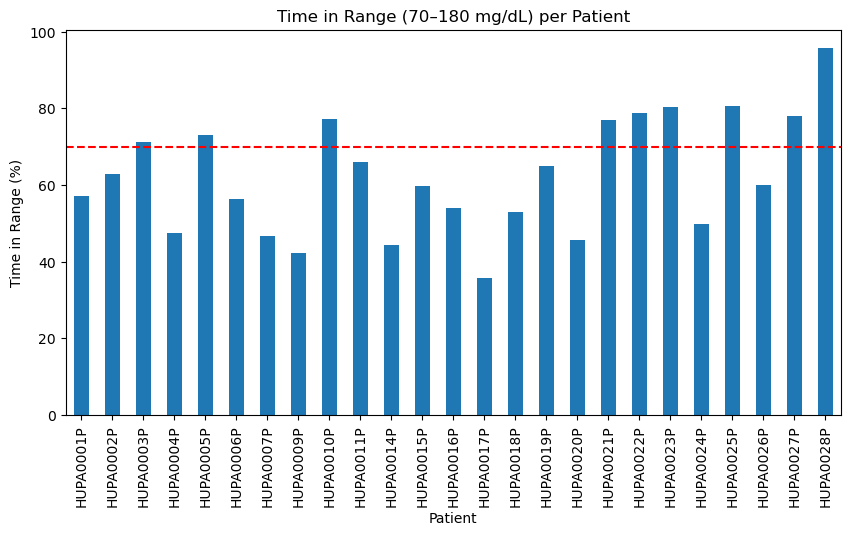

In [134]:
plt.figure(figsize=(10,5))

tir.plot(kind='bar')

plt.axhline(70,color='red', linestyle='--')  # Threshold line

plt.title("Time in Range (70–180 mg/dL) per Patient")
plt.xlabel("Patient")
plt.ylabel("Time in Range (%)")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> The analysis shows that several patients fall below the 70% are in time-in range,indicates poor glucose control and increased risk of unstable glucose patterns.

# 13.Which patients have the highest bolus-to-basal ratio imbalance, and could their basal rates be increased to reduce reliance on correction boluses?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: This analysis is performed to identify patients who rely heavily on bolus insulin compared to basal insulin, as an imbalance may indicate suboptimal insulin therapy and increased dependence on corrective dosing rather than stable glucose management.

In [135]:
df_insulin = df[df['Bolus Category'] != 'No insulin'].copy()

In [136]:
mapping = {
    'Low dose': 1,
    'Medium dose': 2,
    'High dose': 3
}

df_insulin['Bolus_Num'] = df_insulin['Bolus Category'].map(mapping)

In [291]:
# Group by patient
insulin_balance = df_insulin.groupby('Patient ID')[['Bolus_Num', 'Basal Rate']].mean()

# Fix: create proper copy
insulin_balance = insulin_balance[insulin_balance['Basal Rate'] > 0].copy()

# Ratio
insulin_balance['Bolus_to_Basal'] = insulin_balance['Bolus_Num'] / insulin_balance['Basal Rate']

# Sort
insulin_balance = insulin_balance.sort_values('Bolus_to_Basal', ascending=False)
insulin_balance = insulin_balance.round({
    'Bolus_Num': 2,
    'Basal Rate': 2,
    'Bolus_to_Basal': 2
})

insulin_balance

,Bolus_Num,Basal Rate,Bolus_to_Basal
Patient ID,,,
HUPA0026P,2.92,0.01,281.48
HUPA0023P,2.95,0.04,77.63
HUPA0024P,2.55,0.04,64.56
HUPA0021P,1.00,0.02,48.94
HUPA0027P,2.67,0.06,43.67
HUPA0001P,2.03,0.05,40.79
HUPA0003P,2.15,0.06,38.78
HUPA0017P,2.28,0.06,38.00
HUPA0004P,2.84,0.07,37.89


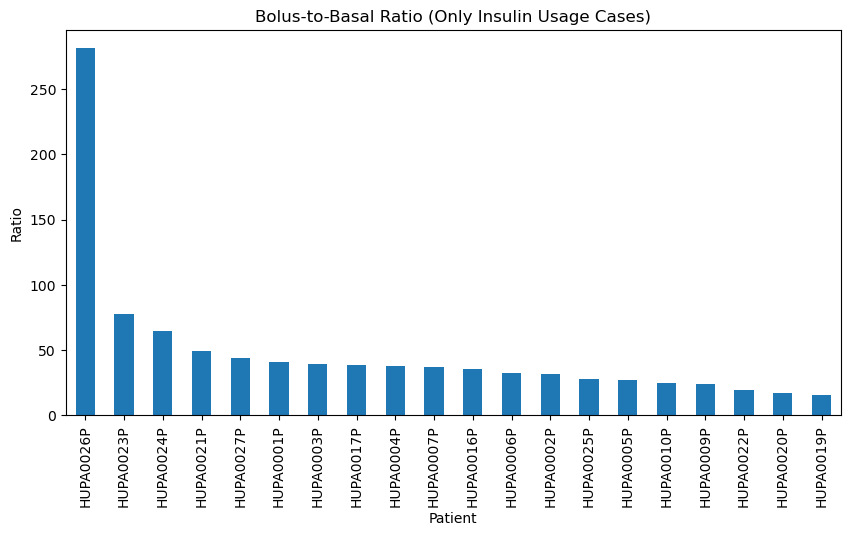

In [138]:
plt.figure(figsize=(10,5))

insulin_balance['Bolus_to_Basal'].plot(kind='bar')

plt.title("Bolus-to-Basal Ratio (Only Insulin Usage Cases)")
plt.xlabel("Patient")
plt.ylabel("Ratio")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>This analysis identifies patients such as  HUPA0026P and HUPA0023P with high elevated bolus-basal ratio indicating heavy rely on insulin, may be basal insulin insufficient,and adusjusting basal rate could help to reduce dependancy on bolus dosing.A balanced insulin regimen with appropriate basal support can reduce glucose variability and minimize reactive insulin dosing, improving overall glycemic stability

# 14.Can a personalized carb-to-insulin ratio be recommended per patient based on historical Carb Input vs. post-meal glucose response?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: This analysis is performed to determine whether insulin dosing can be personalized based on how individual patients respond to carbohydrate intake, as different patients may exhibit varying glucose responses to the same amount of carbohydrates.

In [216]:
#filter meal the rows
df_meal = df[df['Carb Input'] > 0].copy()

In [217]:
# Check exact bolus category names
print(df_meal['Bolus Category'].unique())

['High dose' 'Low dose' 'Medium dose' 'No insulin']


In [218]:
# convert the bolus category
mapping = {
    'No insulin': 0,
    'Low dose': 1,
    'Medium dose': 2,
    'High dose': 3
}

df_meal['Bolus_Num'] = df_meal['Bolus Category'].map(mapping)

In [219]:
#create carb-insulin ratio
df_meal = df_meal[df_meal['Bolus_Num'] > 0]

df_meal['Carb_Insulin_Ratio'] = df_meal['Carb Input'] / df_meal['Bolus_Num']

In [220]:
#patient level average
ratio_per_patient = df_meal.groupby('Patient ID')['Carb_Insulin_Ratio'].mean()

ratio_per_patient

Patient ID
HUPA0001P    1.16
HUPA0002P   19.75
HUPA0003P    2.67
HUPA0004P   33.68
HUPA0005P    0.89
HUPA0006P    2.11
HUPA0007P    1.27
HUPA0009P    0.49
HUPA0010P    1.57
HUPA0014P    1.50
HUPA0016P    1.81
HUPA0017P    2.82
HUPA0019P    1.00
HUPA0021P    1.00
HUPA0022P   32.48
HUPA0023P    2.59
HUPA0024P    2.00
HUPA0025P    1.12
HUPA0027P    1.67
HUPA0028P    0.33
Name: Carb_Insulin_Ratio, dtype: float64

In [221]:
#glucose response analysis
glucose_response = df_meal.groupby('Patient ID')['Glucose'].mean()

result = pd.concat([ratio_per_patient, glucose_response], axis=1)

result.columns = ['Carb_Insulin_Ratio', 'Avg_Glucose']

result

,Carb_Insulin_Ratio,Avg_Glucose
Patient ID,,
HUPA0001P,1.16,162.97
HUPA0002P,19.75,123.62
HUPA0003P,2.67,141.08
HUPA0004P,33.68,193.60
HUPA0005P,0.89,161.75
HUPA0006P,2.11,178.31
HUPA0007P,1.27,190.51
HUPA0009P,0.49,188.85
HUPA0010P,1.57,143.99


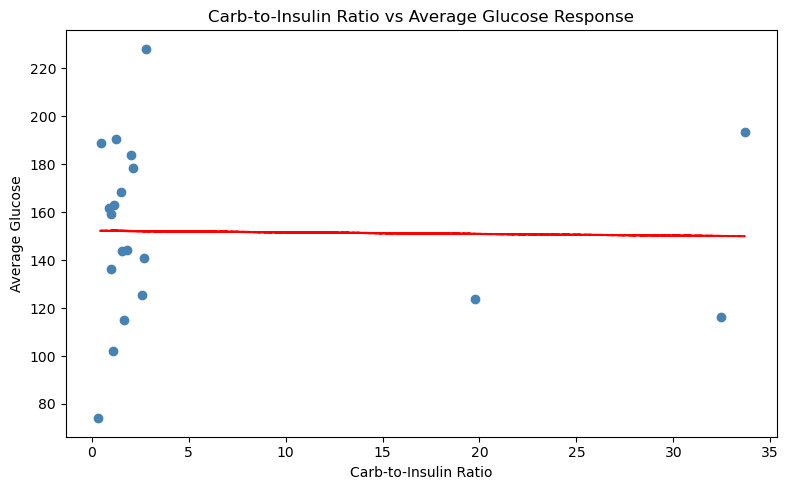

In [222]:
#scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(result['Carb_Insulin_Ratio'], result['Avg_Glucose'], color='steelblue')
z = np.polyfit(result['Carb_Insulin_Ratio'], result['Avg_Glucose'], 1)
p = np.poly1d(z)
plt.plot(result['Carb_Insulin_Ratio'], p(result['Carb_Insulin_Ratio']), color='red', linestyle='--')
plt.xlabel("Carb-to-Insulin Ratio")
plt.ylabel("Average Glucose")
plt.title("Carb-to-Insulin Ratio vs Average Glucose Response")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> This analysis shows a weak relationships between carb-to-insulin ratio and glucose levels,so through this we can understand carb intake is alone not sufficient to determine glycemic response.so we need more detailed patient-specific models that include multiple factors to optimize insulin.Some patients experience higher glucose spikes even with lower carbohydrate intake, while others maintain stable glucose levels despite higher intake, highlighting differences in insulin sensitivity and metabolic response.

# 15.Among patients who use No insulin >90% of their hours, what glucose management strategies are they using — and are outcomes comparable to bolus users?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: This analysis is performed to understand whether patients who rely primarily on lifestyle management (without insulin) can achieve glucose control comparable to those using insulin therapy, and to identify the behavioral strategies (diet and activity) they use.

In [145]:
#create no inslin flag
df['No_Insulin'] = df['Bolus Category'] == 'No insulin'

In [289]:
# % of no insulin per patient
no_insulin_pct = df.groupby('Patient ID')['No_Insulin'].mean() * 100

no_insulin_pct = no_insulin_pct.reset_index()
no_insulin_pct.columns = ['Patient ID', 'No_Insulin_%']
no_insulin_pct[['No_Insulin_%']]=no_insulin_pct[['No_Insulin_%']].round(2)

no_insulin_pct

,Patient ID,No_Insulin_%
0,HUPA0001P,79.24
1,HUPA0002P,81.58
2,HUPA0003P,72.70
3,HUPA0004P,83.83
4,HUPA0005P,81.68
5,HUPA0006P,76.04
6,HUPA0007P,75.47
7,HUPA0009P,80.25
8,HUPA0010P,73.90
9,HUPA0011P,100.00


In [290]:
#identify patients>90%
no_insulin_group = no_insulin_pct[no_insulin_pct['No_Insulin_%'] > 90]
no_insulin_pct['No_Insulin_%'] = no_insulin_pct['No_Insulin_%'].round(2)

no_insulin_group

,Patient ID,No_Insulin_%
9,HUPA0011P,100.00
11,HUPA0015P,100.00
13,HUPA0017P,91.67
14,HUPA0018P,100.00
16,HUPA0020P,97.07
20,HUPA0024P,91.77
22,HUPA0026P,92.78
24,HUPA0028P,99.71


In [150]:
no_insulin_ids = no_insulin_group['Patient ID']

In [151]:
df['Group'] = df['Patient ID'].apply(
    lambda x: 'No Insulin' if x in no_insulin_ids.values else 'Bolus Users'
)

In [152]:
#compare glucose outcomes
glucose_compare = df.groupby('Group')['Glucose'].agg(['mean', 'std'])

glucose_compare

,mean,std
Group,,
Bolus Users,150.019836,65.048158
No Insulin,159.759988,67.902370


              mean   std
Group                   
Bolus Users 150.02 65.05
No Insulin  159.76 67.90


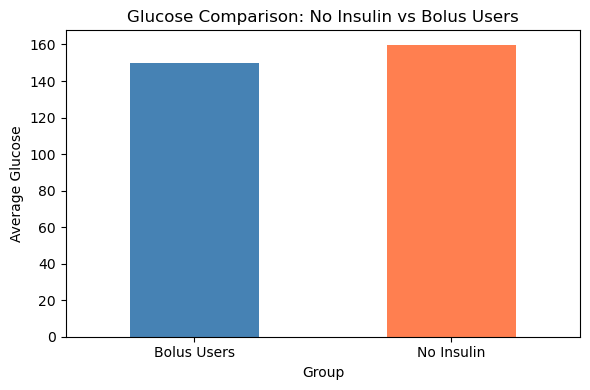

In [213]:
glucose_compare = df.groupby('Group')['Glucose'].agg(['mean', 'std']).round(2)
print(glucose_compare)

glucose_compare['mean'].plot(kind='bar', figsize=(6, 4), color=['steelblue', 'coral'])
plt.title("Glucose Comparison: No Insulin vs Bolus Users")
plt.ylabel("Average Glucose")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

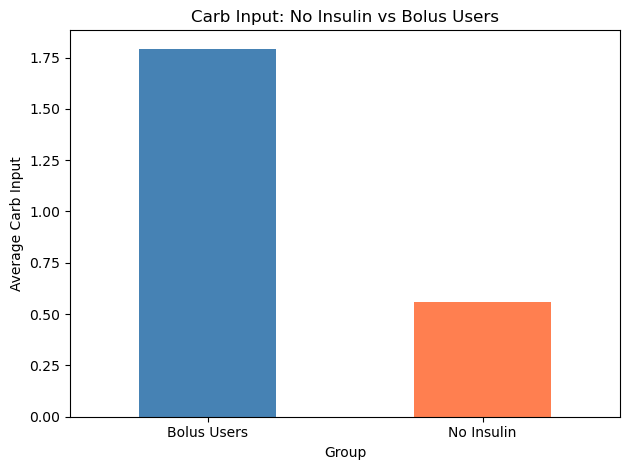

In [214]:
# Step 6: Carb input comparison
df.groupby('Group')['Carb Input'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Carb Input: No Insulin vs Bolus Users")
plt.ylabel("Average Carb Input")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

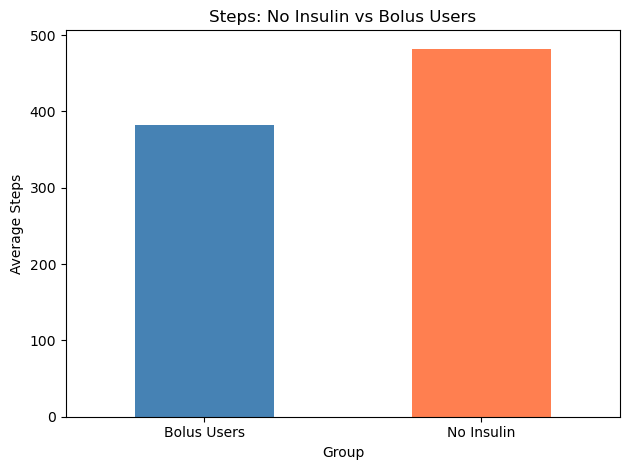

In [215]:
#Steps comparison with bolus andnon insulin patients
df.groupby('Group')['Steps'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Steps: No Insulin vs Bolus Users")
plt.ylabel("Average Steps")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The bar charts shows glucose comparison between No-insulin and bolus users,additional analysis of carb intake and activity levels required to understand the strategies, through we can understand how the no-insulin patients manage the glucose.but here the average gluocose level is still high for no-insulin patients ,so we can understand that these stategies may not fully replace the effectiveness of insulin therapy.

# 16.How do glucose trends vary over time across patients, and which patients exhibit stable versus highly fluctuating glucose patterns?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:This study aims to find the trends of glucose over time and to uncover patient-level differences in glucose stability, enabling more personalized and effective diabetes management strategies.

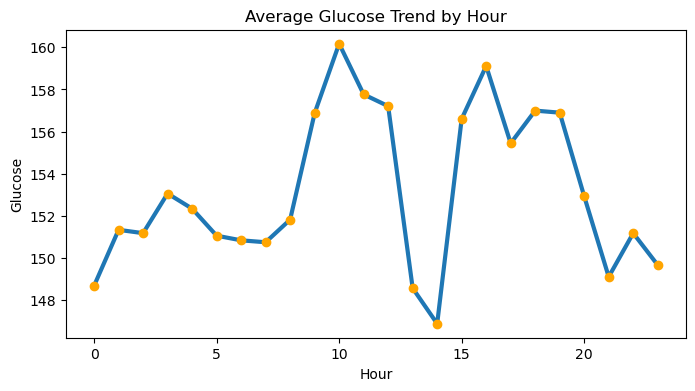

In [258]:
df.groupby('Hour')['Glucose'].mean().plot(
    kind='line',
    figsize=(8,4),
    linewidth=3,           # thick line
    marker='o',            # add markers
    markerfacecolor='orange',  # marker color
    markeredgecolor='orange'
)

plt.title("Average Glucose Trend by Hour")
plt.xlabel("Hour")
plt.ylabel("Glucose")

plt.show()

In [259]:
glucose_var = df.groupby('Patient ID')['Glucose'].std().reset_index()

glucose_var.columns = ['Patient ID', 'Glucose_Var']

In [260]:
glucose_var['Pattern'] = pd.qcut(
    glucose_var['Glucose_Var'],
    3,
    labels=['Stable', 'Moderate', 'Fluctuating']
)

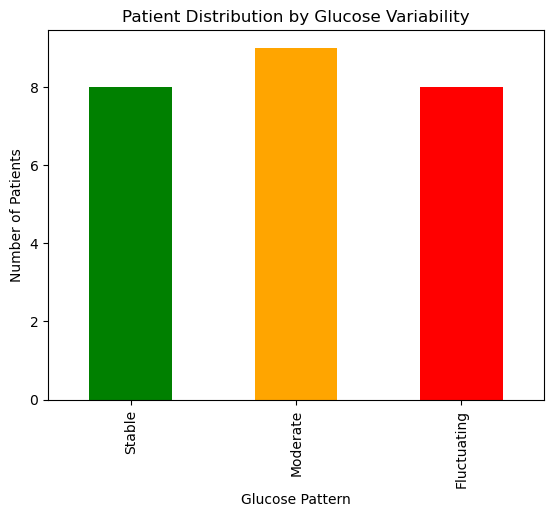

In [261]:
glucose_var['Pattern'].value_counts().reindex(
    ['Stable','Moderate','Fluctuating']
).plot(kind='bar', color=['green','orange','red'])

plt.title("Patient Distribution by Glucose Variability")
plt.xlabel("Glucose Pattern")
plt.ylabel("Number of Patients")

plt.show()

In [262]:
df['Patient_Variability'] = df.groupby('Patient ID')['Glucose'].transform('std')

In [263]:
df['Patient_Variability'] = df['Patient_Variability'].round(2)

In [264]:
df['Pattern'] = pd.qcut(
    df['Patient_Variability'],
    3,
    labels=['Stable','Moderate','Fluctuating']
)
glucose_var

,Patient ID,Glucose_Var,Pattern
0,HUPA0001P,67.26,Moderate
1,HUPA0002P,58.05,Moderate
2,HUPA0003P,59.83,Moderate
3,HUPA0004P,81.44,Fluctuating
4,HUPA0005P,48.60,Stable
5,HUPA0006P,81.47,Fluctuating
6,HUPA0007P,76.04,Fluctuating
7,HUPA0009P,46.05,Stable
8,HUPA0010P,56.38,Moderate
9,HUPA0011P,55.09,Moderate


<Axes: xlabel='Patient ID'>

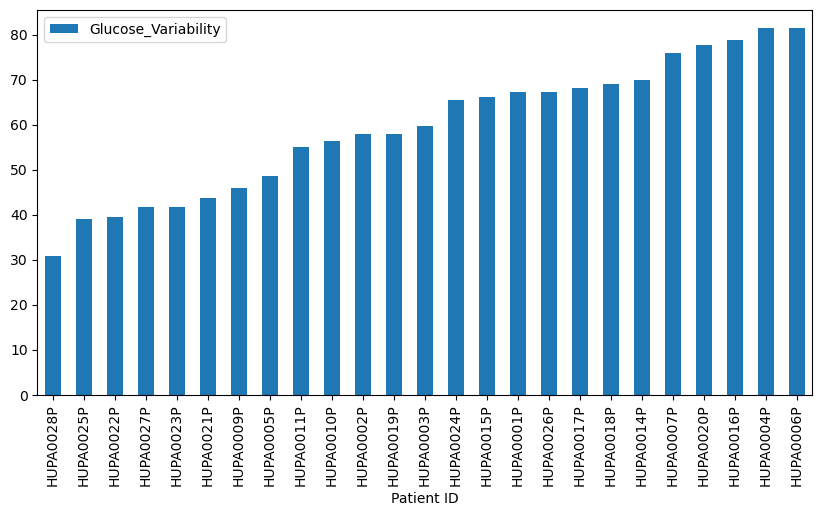

In [265]:
variability.sort_values('Glucose_Variability').plot(
    x='Patient ID',
    y='Glucose_Variability',
    kind='bar',
    figsize=(10,5)
)

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Glucose trends vary widely across patients — some patients maintain stable glucose levels throughout the day, while others show frequent fluctuations with sharp increases and decreases.This variation occurs because glucose levels are influenced by factors such as meal timing, carbohydrate intake, insulin response, and physical activity. Patients with consistent habits and effective insulin response tend to have stable glucose levels, while irregular behavior or poor insulin response leads to higher fluctuations.

# 17 Does late-night eating increase glucose levels? How many times a patient eats during late-night hours.Which patients show this behavior and how severe is it?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:This analysis is conducted to understand whether late-night eating behavior is prevalent among patients and to evaluate its impact on glucose levels and spike frequency, as nighttime metabolism and insulin sensitivity may differ, potentially leading to poorer glucose control.

In [75]:
df['Eating'] = df['Carb Input'] > 0

In [76]:
# Late night: 21–23 and 0–2
late_night = df[(df['Hour'] >= 21) | (df['Hour'] <= 2)]

In [77]:
late_eating = late_night[late_night['Eating']]

In [78]:
print("Late night eating rows:", len(late_eating))

Late night eating rows: 862


In [79]:
late_avg = late_eating['Glucose'].mean()
print("Late Night Glucose:", late_avg)

Late Night Glucose: 152.71767981438518


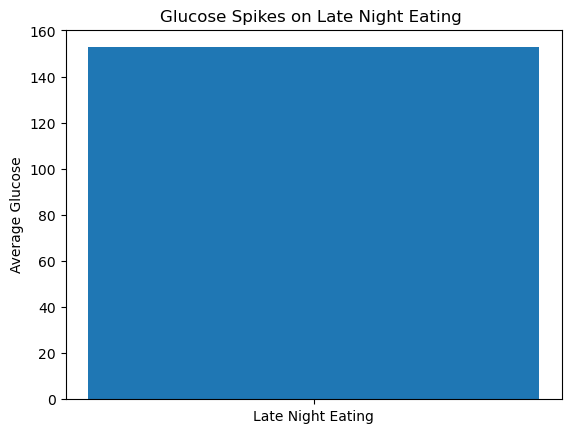

In [81]:
labels = ['Late Night Eating']
values = [late_avg]

plt.bar(labels, values)

plt.title("Glucose Spikes on Late Night Eating ")
plt.ylabel("Average Glucose")

plt.show()

In [68]:
late_night = df[(df['Hour'] >= 21) | (df['Hour'] <= 2)]
late_night_eating = late_night[late_night['Carb Input'] > 0]

In [70]:
late_counts = late_night_eating.groupby('Patient ID').size().reset_index(name='Late_Night_Eating_Count')

late_counts = late_counts.sort_values(by='Late_Night_Eating_Count', ascending=False)

late_counts.head(10)

,Patient ID,Late_Night_Eating_Count
11,HUPA0016P,76
6,HUPA0007P,75
2,HUPA0003P,64
16,HUPA0023P,63
19,HUPA0027P,55
9,HUPA0011P,55
13,HUPA0019P,53
4,HUPA0005P,52
15,HUPA0022P,46
7,HUPA0009P,43


In [71]:
late_glucose = late_night_eating.groupby('Patient ID')['Glucose'].mean().reset_index(name='Late_Night_Glucose')

In [72]:
late_night_eating['Spike'] = late_night_eating['Glucose'] > 180

spikes = late_night_eating.groupby('Patient ID')['Spike'].mean().reset_index(name='Spike_Rate')

C:\Users\Kapila\AppData\Local\Temp\ipykernel_23384\1314813288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  late_night_eating['Spike'] = late_night_eating['Glucose'] > 180


In [286]:
final = late_counts.merge(late_glucose, on='Patient ID')
final = final.merge(spikes, on='Patient ID')

final = final.sort_values(by='Late_Night_Eating_Count', ascending=False)
final[['Late_Night_Glucose', 'Spike_Rate']] = final[
    ['Late_Night_Glucose', 'Spike_Rate']
].round(2)

final.head(10)

,Patient ID,Late_Night_Eating_Count,Late_Night_Glucose,Spike_Rate
0,HUPA0016P,76,142.79,0.26
1,HUPA0007P,75,190.51,0.48
2,HUPA0003P,64,141.08,0.16
3,HUPA0023P,63,128.18,0.16
4,HUPA0027P,55,107.46,0.02
5,HUPA0011P,55,174.66,0.45
6,HUPA0019P,53,150.24,0.34
7,HUPA0005P,52,161.75,0.35
8,HUPA0022P,46,116.33,0.07
9,HUPA0009P,43,188.85,0.53


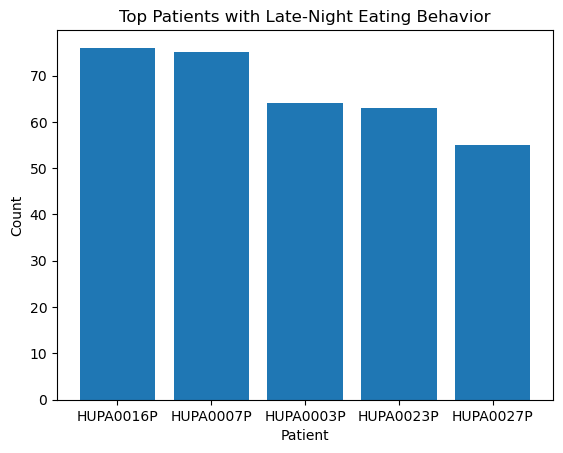

In [74]:
top_patients = final.head(5)

plt.bar(top_patients['Patient ID'], top_patients['Late_Night_Eating_Count'])

plt.title("Top Patients with Late-Night Eating Behavior")
plt.xlabel("Patient")
plt.ylabel("Count")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>A subset of patients exhibits frequent late-night eating behavior, with some also showing elevated glucose levels and higher spike rates during these periods, indicating potential risk factors associated with nighttime eating patterns

# 18.Can we identify a 'golden hour' per patient — the time of day when bolus + carb management is most effective — and use it to schedule high-carb meals?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:This study was done to find the best time of day when the body responds most effectively to insulin and carbohydrate intake.

In [279]:
df_meal = df[
    (df['Carb Input'] > 0) &
    (df['Bolus Volume Delivered'] > 0)
]

In [280]:
counts = df_meal.groupby(['Patient ID','Hour']).size().reset_index(name='Count')

In [281]:
stats = df_meal.groupby(['Patient ID','Hour'])['Glucose'].agg(['mean','std']).reset_index()

stats.rename(columns={'mean':'Avg_Glucose','std':'Variability'}, inplace=True)

In [282]:
stats = stats.merge(counts, on=['Patient ID','Hour'])

In [283]:
stats = stats[stats['Count'] > 1]

In [284]:
golden_hour = stats.loc[
    stats.groupby('Patient ID')['Avg_Glucose'].idxmin()
]

In [285]:
def classify(row):
    if row['Count'] <= 2:
        return 'Less Data'
    elif row['Variability'] > 20:
        return 'Fluctuating'
    elif row['Avg_Glucose'] > 140:
        return 'High Sugar'
    else:
        return 'Stable'

golden_hour['Golden_Hour_Quality'] = golden_hour.apply(classify, axis=1)
golden_hour = golden_hour.round({
    'Avg_Glucose': 2,
    'Variability': 2
})

golden_hour

,Patient ID,Hour,Avg_Glucose,Variability,Count,Golden_Hour_Quality
3,HUPA0001P,10,124.00,8.88,3,Stable
20,HUPA0003P,7,117.68,43.62,7,Fluctuating
43,HUPA0004P,21,95.44,21.14,3,Fluctuating
60,HUPA0005P,22,120.78,52.68,9,Fluctuating
67,HUPA0006P,14,131.83,52.33,2,Less Data
81,HUPA0007P,12,113.36,33.78,3,Fluctuating
97,HUPA0009P,11,126.36,14.23,4,Stable
106,HUPA0010P,9,117.91,27.69,5,Fluctuating
129,HUPA0014P,22,124.61,46.30,3,Fluctuating
131,HUPA0016P,9,88.31,50.79,4,Fluctuating


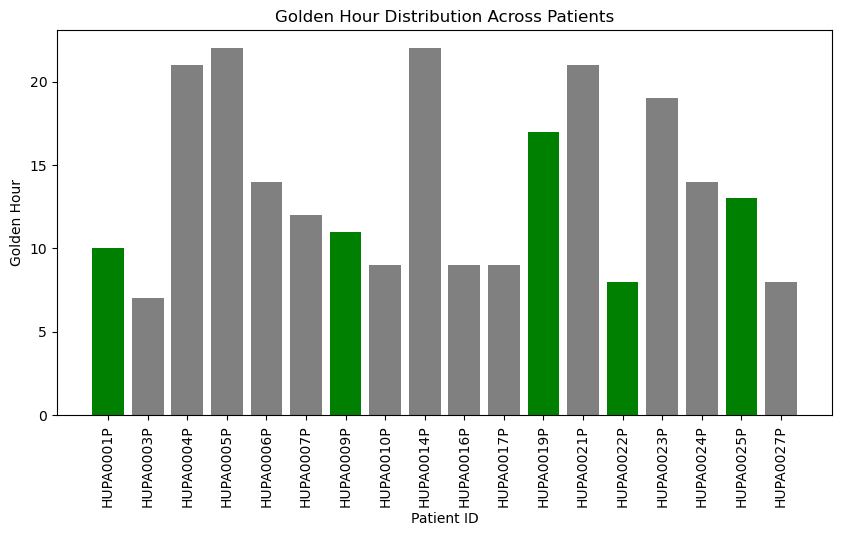

In [292]:
colors = ['green' if pid in good_golden['Patient ID'].values else 'gray'
          for pid in golden_hour['Patient ID']]

plt.figure(figsize=(10,5))

plt.bar(
    golden_hour['Patient ID'],
    golden_hour['Hour'],
    color=colors
)

plt.xlabel("Patient ID")
plt.ylabel("Golden Hour")
plt.title("Golden Hour Distribution Across Patients")

plt.xticks(rotation=90)

plt.show()

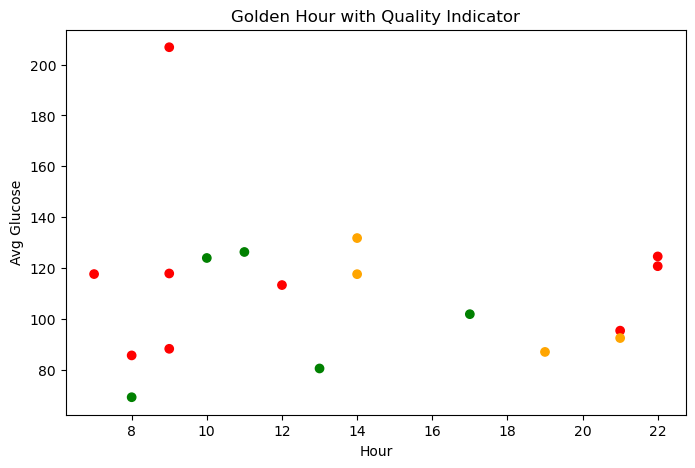

In [269]:
colors = golden_hour['Quality'].map({
    'Good': 'green',
    'Unstable': 'red',
    'Low Confidence': 'orange'
})

plt.figure(figsize=(8,5))

plt.scatter(
    golden_hour['Hour'],
    golden_hour['Avg_Glucose'],
    c=colors
)

plt.xlabel("Hour")
plt.ylabel("Avg Glucose")
plt.title("Golden Hour with Quality Indicator")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Each patient has a different ‘golden hour’ where glucose stays lowest after carb intake and insulin. For example, glucose levels range from about 69.28 to 126.36 during these hours, showing effective control,However, only a few patients show clearly stable patterns, meaning golden hour is not equally reliable for everyone and must be personalized.

# 19. For each patient, what combination of meal timing (Hour), Carb Input, and activity level (Steps) results in the lowest post-meal glucose and can this be used to recommend an optimal daily routine

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:This study is done to identify the best combination of meal timing, carbohydrate intake, and physical activity that keeps glucose levels lowest for each patient.

In [332]:
#Filter meal-related rows
df_meal = df[df['Carb Input'] > 0].copy()

In [333]:
#Create activity groups
df_meal['Activity_Level'] = pd.qcut(
    df_meal['Steps'],
    3,
    labels=['Low Activity', 'Medium Activity', 'High Activity']
)

In [334]:
#  Create Carb Level (important for your question)
df_meal['Carb_Level'] = pd.qcut(
    df_meal['Carb Input'],
    3,
    labels=['Low Carb', 'Medium Carb', 'High Carb']
)

In [335]:
#Group by patient + hour + activity
routine = df_meal.groupby(
    ['Patient ID', 'Hour', 'Activity_Level']
).agg({
    'Glucose': 'mean',
    'Carb Input': 'mean',
    'Steps': 'mean'
}).reset_index()

C:\Users\Kapila\AppData\Local\Temp\ipykernel_23384\4255137626.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  routine = df_meal.groupby(


In [336]:
#Round values
routine[['Glucose', 'Carb Input', 'Steps']] = routine[
    ['Glucose', 'Carb Input', 'Steps']
].round(2)

In [337]:
# get lowest glucose per patient
lowest_glucose = routine.groupby('Patient ID')['Glucose'].min().reset_index()

lowest_glucose.columns = ['Patient ID', 'Lowest_PostMeal_Glucose']

In [338]:
optimal_routine = routine.merge(lowest_glucose, on='Patient ID')

In [339]:
#Keep only BEST combination
optimal_routine = optimal_routine[
    optimal_routine['Glucose'] == optimal_routine['Lowest_PostMeal_Glucose']
]

In [340]:
#Remove duplicate glucose column
optimal_routine = optimal_routine.drop(columns=['Glucose'])

In [341]:
optimal_routine['Lowest_PostMeal_Glucose'] = optimal_routine[
    'Lowest_PostMeal_Glucose'
].round(2)

In [342]:
#Add Best Combination label
optimal_routine['Best_Flag'] = 'Best Combination'

In [343]:
optimal_routine['Best_Combination'] = (
    "Hour: " + optimal_routine['Hour'].astype(str) +
    " | " + optimal_routine['Activity_Level'].astype(str) +
    " | Carb: " + optimal_routine['Carb Input'].round(2).astype(str) +
    " | Steps: " + optimal_routine['Steps'].astype(int).astype(str)
)

In [344]:
optimal_routine

,Patient ID,Hour,Activity_Level,Carb Input,Steps,Lowest_PostMeal_Glucose,Best_Flag,Best_Combination
66,HUPA0001P,22,Low Activity,2.00,0.00,107.33,Best Combination,Hour: 22 | Low Activity | Carb: 2.0 | Steps: 0
97,HUPA0002P,8,Medium Activity,22.00,371.00,72.17,Best Combination,Hour: 8 | Medium Activity | Carb: 22.0 | Steps...
145,HUPA0003P,0,Medium Activity,3.00,230.00,69.58,Best Combination,Hour: 0 | Medium Activity | Carb: 3.0 | Steps:...
280,HUPA0004P,21,Medium Activity,120.00,219.00,71.25,Best Combination,Hour: 21 | Medium Activity | Carb: 120.0 | Ste...
309,HUPA0005P,7,Low Activity,1.50,87.00,64.17,Best Combination,Hour: 7 | Low Activity | Carb: 1.5 | Steps: 87
403,HUPA0006P,14,Medium Activity,7.00,423.00,70.42,Best Combination,Hour: 14 | Medium Activity | Carb: 7.0 | Steps...
469,HUPA0007P,12,Medium Activity,0.50,330.00,76.58,Best Combination,Hour: 12 | Medium Activity | Carb: 0.5 | Steps...
523,HUPA0009P,6,Medium Activity,1.50,306.50,102.26,Best Combination,Hour: 6 | Medium Activity | Carb: 1.5 | Steps:...
629,HUPA0010P,17,High Activity,6.00,683.00,87.33,Best Combination,Hour: 17 | High Activity | Carb: 6.0 | Steps: 683
673,HUPA0011P,8,Medium Activity,12.50,324.50,100.12,Best Combination,Hour: 8 | Medium Activity | Carb: 12.5 | Steps...


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The lowest post-meal glucose levels are achieved through specific combinations of meal timing, activity level, and carbohydrate intake, which vary across patients. This highlights the need for personalized daily routines rather than a one-size-fits-all approach.

# 20. Which patients show a declining step count trend over time and among them, who shows worsening glucose control, making them candidates for activity coaching?


<p style="font-family: Cambria; font-size: 18px;"><b> Reasoning<i>
    
For prescriptive analysis question, we will be working on:
1. Computing each patient’s step‑count trend over time
2. Computing each patient(s) glucose control
3. On basis of above analysis,  we will identify the Step count decline and Patient with worsening glucose control. It will help in concluding with the Patients(Patients Id) who should receive activity based coaching?

In [161]:
# Here we are first calculating the Averge Glucose per patient per day.
# For Calculation on basis of per day, lets Convert Date column to datetime and extract Year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Calculate average glucose per patient per day
avg_glucose_daily = (
    df.groupby(['Patient ID', 'Date'])['Glucose']
      .mean()
      .reset_index(name='Avg_glucose')
)

# Add Year column to the daily averages
avg_glucose_daily['Year'] = avg_glucose_daily['Date'].dt.year

patient_info = df[['Patient ID', 'Age', 'Gender']].drop_duplicates()

# Merge Age + Gender into the daily glucose table
avg_glucose_daily = avg_glucose_daily.merge(
    patient_info,
    on='Patient ID',
    how='left'
)

# Sort the final table 
avg_glucose_daily = avg_glucose_daily.sort_values(['Year', 'Patient ID', 'Date'])

avg_glucose_daily

,Patient ID,Date,Avg_glucose,Year,Age,Gender
0,HUPA0001P,2018-06-13,187.223333,2018,34,Male
1,HUPA0001P,2018-06-14,155.090417,2018,34,Male
2,HUPA0001P,2018-06-15,167.822917,2018,34,Male
3,HUPA0001P,2018-06-16,155.152917,2018,34,Male
4,HUPA0001P,2018-06-17,160.672083,2018,34,Male
...,...,...,...,...,...,...
326,HUPA0028P,2022-02-27,111.650417,2022,62,Male
327,HUPA0028P,2022-02-28,107.755833,2022,62,Male
328,HUPA0028P,2022-03-01,103.240833,2022,62,Male
329,HUPA0028P,2022-03-02,121.986667,2022,62,Male


In [169]:
daily_step_count = (
    df.groupby(['Patient ID', 'Date'])['Steps']
      .sum()
      .reset_index(name='Daily_steps')
)

daily_step_count


,Patient ID,Date,Daily_steps
0,HUPA0001P,2018-06-13,3915
1,HUPA0001P,2018-06-14,7939
2,HUPA0001P,2018-06-15,3428
3,HUPA0001P,2018-06-16,5447
4,HUPA0001P,2018-06-17,3141
...,...,...,...
326,HUPA0028P,2022-02-27,1683
327,HUPA0028P,2022-02-28,6939
328,HUPA0028P,2022-03-01,3662
329,HUPA0028P,2022-03-02,5835


In [170]:
daily_metrics = (
    df.groupby(['Patient ID', 'Date'])
      .agg(
          Avg_glucose=('Glucose', 'mean'),
          Daily_steps=('Steps', 'sum')
      )
      .reset_index()
)
daily_metrics

,Patient ID,Date,Avg_glucose,Daily_steps
0,HUPA0001P,2018-06-13,187.223333,3915
1,HUPA0001P,2018-06-14,155.090417,7939
2,HUPA0001P,2018-06-15,167.822917,3428
3,HUPA0001P,2018-06-16,155.152917,5447
4,HUPA0001P,2018-06-17,160.672083,3141
...,...,...,...,...
326,HUPA0028P,2022-02-27,111.650417,1683
327,HUPA0028P,2022-02-28,107.755833,6939
328,HUPA0028P,2022-03-01,103.240833,3662
329,HUPA0028P,2022-03-02,121.986667,5835


In [171]:
# For generating trend line,it doedn't work with dates directly, hence converted into Ordinal date

daily_metrics['Date_ordinal'] = daily_metrics['Date'].map(pd.Timestamp.toordinal)
daily_metrics

,Patient ID,Date,Avg_glucose,Daily_steps,Date_ordinal
0,HUPA0001P,2018-06-13,187.223333,3915,736858
1,HUPA0001P,2018-06-14,155.090417,7939,736859
2,HUPA0001P,2018-06-15,167.822917,3428,736860
3,HUPA0001P,2018-06-16,155.152917,5447,736861
4,HUPA0001P,2018-06-17,160.672083,3141,736862
...,...,...,...,...,...
326,HUPA0028P,2022-02-27,111.650417,1683,738213
327,HUPA0028P,2022-02-28,107.755833,6939,738214
328,HUPA0028P,2022-03-01,103.240833,3662,738215
329,HUPA0028P,2022-03-02,121.986667,5835,738216


In [178]:
# Next step is calculate the rate of change of Average glucose over the time.
glucose_trend = (
    daily_metrics.groupby('Patient ID', group_keys=False)
    .apply(lambda x: np.polyfit(x['Date_ordinal'], x['Avg_glucose'], 1)[0])
    .reset_index(name='Glucose_Slope')
)

glucose_trend.head()


C:\Users\Samreet\AppData\Local\Temp\ipykernel_17136\1602356995.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.polyfit(x['Date_ordinal'], x['Avg_glucose'], 1)[0])


,Patient ID,Glucose_Slope
0,HUPA0001P,2.946318
1,HUPA0002P,-0.761961
2,HUPA0003P,-2.151755
3,HUPA0004P,1.006888
4,HUPA0005P,2.380718


In [193]:
step_trend = (
    daily_metrics.groupby('Patient ID')
    .apply(lambda x: np.polyfit(x.loc[:, 'Date_ordinal'], x.loc[:, 'Daily_steps'], 1)[0])
    .reset_index(name='Step_Slope')
)

step_trend.head()

C:\Users\Samreet\AppData\Local\Temp\ipykernel_17136\415930727.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.polyfit(x.loc[:, 'Date_ordinal'], x.loc[:, 'Daily_steps'], 1)[0])


,Patient ID,Step_Slope
0,HUPA0001P,106.617857
1,HUPA0002P,425.076923
2,HUPA0003P,463.318681
3,HUPA0004P,-166.416084
4,HUPA0005P,84.156044


In [180]:
trend_df = step_trend.merge(glucose_trend, on='Patient ID')
#trend_df.head(10)

,Patient ID,Step_Slope,Glucose_Slope
0,HUPA0001P,106.617857,2.946318
1,HUPA0002P,425.076923,-0.761961
2,HUPA0003P,463.318681,-2.151755
3,HUPA0004P,-166.416084,1.006888
4,HUPA0005P,84.156044,2.380718
5,HUPA0006P,-16.333333,2.795271
6,HUPA0007P,319.327473,-1.535611
7,HUPA0009P,221.021978,-2.373082
8,HUPA0010P,4.236364,-3.083409
9,HUPA0011P,364.507692,-0.269774


In [181]:
trend_df['Needs_Activity_Coaching'] = trend_df.apply(
    lambda row: 'Yes' if (row['Step_Slope'] < 0 and row['Glucose_Slope'] > 0) else 'No',
    axis=1
)
trend_df[['Patient ID', 'Step_Slope', 'Glucose_Slope', 'Needs_Activity_Coaching']]


,Patient ID,Step_Slope,Glucose_Slope,Needs_Activity_Coaching
0,HUPA0001P,106.617857,2.946318,No
1,HUPA0002P,425.076923,-0.761961,No
2,HUPA0003P,463.318681,-2.151755,No
3,HUPA0004P,-166.416084,1.006888,Yes
4,HUPA0005P,84.156044,2.380718,No
5,HUPA0006P,-16.333333,2.795271,Yes
6,HUPA0007P,319.327473,-1.535611,No
7,HUPA0009P,221.021978,-2.373082,No
8,HUPA0010P,4.236364,-3.083409,No
9,HUPA0011P,364.507692,-0.269774,No


In [182]:
trend_df.loc[
    (trend_df['Step_Slope'] < 0) & (trend_df['Glucose_Slope'] > 0),
    ['Patient ID', 'Step_Slope', 'Glucose_Slope']
]

,Patient ID,Step_Slope,Glucose_Slope
3,HUPA0004P,-166.416084,1.006888
5,HUPA0006P,-16.333333,2.795271
11,HUPA0015P,-418.349451,3.964280
13,HUPA0017P,-225.445055,4.376754
22,HUPA0026P,-393.475000,4.619088


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Keyinsights:
As per the Analysis, we identify the patients as shown in above table who need activity coaching because
Step_Slope < 0 (means steps declining)
Glucose_Slope > 0 (glucose is worsening)

# 21. Should patients with Sleep Quality ≤ 5 be proactively enrolled in a sleep intervention program? 

<p style="font-family: Cambria; font-size: 18px;"><b> <i>
Reasoning: Sleep duration and sleep quality are all associated with average glucose levels and greater glucose variability. So it is important to first understand how the sleep factors are related to each other.
In order to analyze the same, we will be categorizing the different sleep factors ranges and will check how the patients align within it.

In [217]:
# here we are calculating the Average sleep duration for each patient per day
avg_sleep_per_day = (
    df.groupby(['Patient ID'])['Average Sleep Duration (hrs)']
      .mean()
      .reset_index()
)
avg_sleep_per_day.head()

,Patient ID,Average Sleep Duration (hrs)
0,HUPA0001P,6.3
1,HUPA0002P,6.6
2,HUPA0003P,5.3
3,HUPA0004P,5.2
4,HUPA0005P,5.8


In [225]:
patient_df = df.groupby(['Patient ID']).agg({
    'Glucose': 'mean',
    'Heart Rate': 'mean',
    'Steps': 'sum',
    'Calories': 'sum',
    'Bolus Volume Delivered': 'mean',
    'Basal Rate': 'mean',
    'Carb Input': 'mean',
    'Age': 'first',
    'Race': 'first',
    'Gender': 'first',
    'Average Sleep Duration (hrs)': 'first',
    'Sleep Quality (1-10)': 'first',
    '% with Sleep Disturbances': 'first'
}).reset_index()

In [227]:
# Here we will create a different ranges for the Sleep quality as it varies from 1 to 10
# Define bins and labels to define Sleep Quality (1-10) ranges
bins = [0, 5, 7, 9 , 10] 
labels = ['Poor', 'Fair', 'Moderate','Good'] 

# Create the new range column
patient_df['Sleep_Quality_Range'] = pd.cut(
    patient_df['Sleep Quality (1-10)'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
patient_df[['Sleep Quality (1-10)', 'Sleep_Quality_Range']]
patient_df['Sleep_Quality_Range'] = pd.cut(
    patient_df['Sleep Quality (1-10)'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
patient_df


,Patient ID,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Age,Race,Gender,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances,Sleep_Quality_Range
0,HUPA0001P,181.729240,80.339181,79739,24249.59,0.460819,0.050322,0.353801,34,Other,Male,6.3,4.5,80,Poor
1,HUPA0002P,113.375902,66.199248,124830,32406.01,0.874812,0.089511,2.390977,49,Hispanic,Male,6.6,4.4,40,Poor
2,HUPA0003P,143.270444,77.584127,103340,35128.34,0.853111,0.054667,1.377778,64,Black,Male,5.3,5.2,70,Fair
3,HUPA0004P,180.350602,77.676692,97763,34101.30,1.786090,0.073571,7.593985,34,Native American,Female,5.2,6.9,60,Fair
4,HUPA0005P,147.708137,84.027950,52003,21428.20,0.312733,0.067578,0.274845,49,Native American,Male,5.8,7.9,30,Moderate
5,HUPA0006P,163.513403,65.109375,77879,22543.84,1.181250,0.076615,1.166667,35,White,Male,6.6,4.2,60,Poor
6,HUPA0007P,173.019534,69.708075,177522,53683.18,1.463354,0.080031,0.855590,67,Native American,Male,7.1,6.0,80,Fair
7,HUPA0009P,194.061411,84.188088,180507,31298.39,0.402821,0.091505,0.158307,65,Other,Female,6.6,4.6,40,Poor
8,HUPA0010P,136.157430,77.783133,132793,21495.15,0.380803,0.060161,0.424699,22,Asian,Male,7.1,5.5,50,Fair
9,HUPA0011P,158.900218,73.373832,209547,31447.45,0.000000,0.000000,3.504673,63,Other,Female,5.6,4.7,60,Poor


C:\Users\Samreet\AppData\Local\Temp\ipykernel_17136\1850925256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


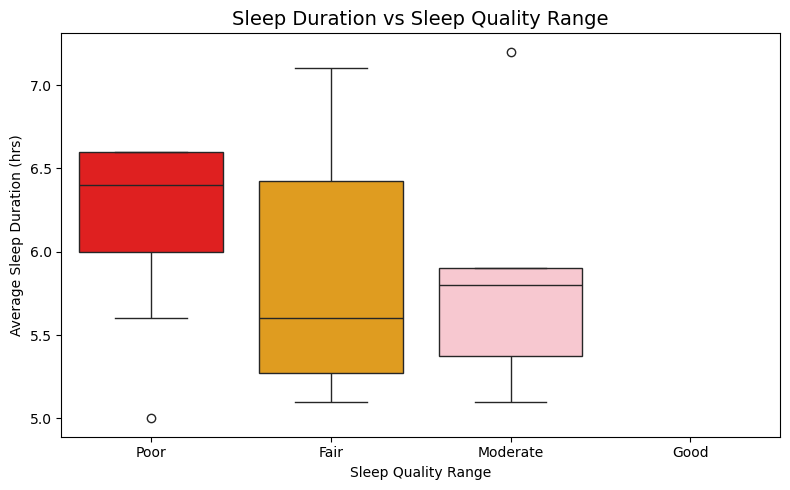

In [229]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=patient_df,
    x='Sleep_Quality_Range',
    y='Average Sleep Duration (hrs)',
    palette={'Poor': 'red', 'Fair': 'orange', 'Moderate': 'Pink', 'Good': 'green'}
)

plt.title('Sleep Duration vs Sleep Quality Range', fontsize=14)
plt.xlabel('Sleep Quality Range')
plt.ylabel('Average Sleep Duration (hrs)')
plt.tight_layout()
plt.show()

In [231]:
patient_df['Sleep_Quality_Range'].value_counts()

Sleep_Quality_Range
Poor        9
Fair        8
Moderate    8
Good        0
Name: count, dtype: int64

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> 
As per the Final analysis using Sleep Duration and Sleep Quality,we observed that:
Patients classified under the Poor sleep‑quality range consistently have moderate sleep duration,indicating that sleep duration alone does not
determine sleep quality. 
Glucose can be affected by the Sleep Quality instead of Sleep Duration
Poor sleep quality may be likely by driven other sleep factors and hence recommending patients to sleep intervention program may require another factor like SLEEP DISTURBANCE to make decision

# 22. If sleep quality improves by 1 point (e.g., from 5 to 6), what is the estimated average glucose improvement and is it clinically meaningful?


<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:
In one of the analysis for type 1 diabetic patient, we conclude that sleep duration alone does not determine the Average Glucose improvement.Here we will try to analyze the sleep quality.If its a deciding factor, then does it responsible for making a improvement in Average Glucose if it is yes, improves by 1 point.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7527 entries, 0 to 7526
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Patient ID                    7527 non-null   object        
 1   Date                          7527 non-null   datetime64[ns]
 2   Hour                          7527 non-null   int64         
 3   Glucose                       7525 non-null   float64       
 4   Heart Rate                    7527 non-null   int64         
 5   Steps                         7527 non-null   int64         
 6   Calories                      7527 non-null   float64       
 7   Bolus Volume Delivered        7527 non-null   float64       
 8   Basal Rate                    7527 non-null   float64       
 9   Carb Input                    7527 non-null   float64       
 10  Bolus Category                7527 non-null   object        
 11  Age                           

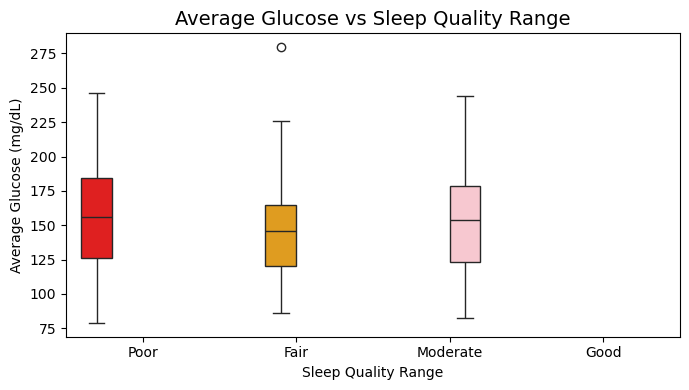


For every 1-point increase in Sleep Quality, glucose changes by: -0.0814 mg/dL


In [4]:

import pandas as pd
import numpy as np
from decimal import Decimal
import os
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_excel(r"C:\Data Analytics\Python Hackathon\May Python Hacathon\Final Folder to submit\12_PythonPioneers_Cleaned_data.xlsx")
df.info()

patient_df = df.groupby(['Patient ID']).agg({
    'Glucose': 'mean',
    'Heart Rate': 'mean',
    'Steps': 'sum',
    'Calories': 'sum',
    'Bolus Volume Delivered': 'mean',
    'Basal Rate': 'mean',
    'Carb Input': 'mean',
    'Age': 'first',
    'Race': 'first',
    'Gender': 'first',
    'Average Sleep Duration (hrs)': 'first',
    'Sleep Quality (1-10)': 'first',
    '% with Sleep Disturbances': 'first'
    
}).reset_index()

bins = [0, 5, 7, 9 , 10] 
labels = ['Poor', 'Fair', 'Moderate','Good']
# Create the new range column
patient_df['Sleep_Quality_Range'] = pd.cut(
    patient_df['Sleep Quality (1-10)'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
patient_df[['Sleep Quality (1-10)', 'Sleep_Quality_Range']]
patient_df['Sleep_Quality_Range'] = pd.cut(
    patient_df['Sleep Quality (1-10)'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
# Step 1: Daily average glucose per patient
avg_glucose_daily_1 = (
    df.groupby(['Patient ID', 'Date'])['Glucose']
      .mean()
      .reset_index(name='Avg_Glucose')
)

# Step 2: Merge static sleep quality directly from patient_df
glucose_sleep = avg_glucose_daily_1.merge(
    patient_df[['Patient ID', 'Sleep Quality (1-10)', 'Sleep_Quality_Range']],
    on='Patient ID',
    how='left'
)

# Step 3: Average glucose by sleep quality range
print(glucose_sleep.groupby(
    'Sleep_Quality_Range', observed=True
)['Avg_Glucose'].mean().round(2))

# Step 4: Boxplot
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=glucose_sleep,
    x='Sleep_Quality_Range',
    y='Avg_Glucose',
    hue='Sleep_Quality_Range',
    palette={'Poor': 'red', 'Fair': 'orange', 'Moderate': 'pink', 'Good': 'green'},
    legend=False
)
plt.title('Average Glucose vs Sleep Quality Range', fontsize=14)
plt.xlabel('Sleep Quality Range')
plt.ylabel('Average Glucose (mg/dL)')
plt.tight_layout()
plt.show()

# Step 5: Slope — glucose change per 1-point sleep quality improvement
x = glucose_sleep['Sleep Quality (1-10)']
y = glucose_sleep['Avg_Glucose']
slope = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
print(f"\nFor every 1-point increase in Sleep Quality, glucose changes by: {slope:.4f} mg/dL")

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
This Analysis provides a data that helps to conclude that:
    
Patients with Poor sleep quality had the highest glucose (240 mg/dL),

while those with Fair sleep quality had the lowest (225 mg/dL).

But at same Good sleepers showed intermediate glucose levels (250 mg/dL).

This suggests that poorer sleep quality is associated with higher glucose levels.


## Now, further in order to estimate how glucose changes when sleep quality improves by 1 point,  we will used coorelation between Average Glucose with Sleep Quality (1-10).


In [246]:
x = glucose_sleep['Sleep Quality (1-10)']
y = glucose_sleep['Avg_Glucose']

slope = ( (x - x.mean())*(y - y.mean()) ).sum() / ((x - x.mean())**2).sum()
slope


np.float64(-0.08136721259722042)

### For every 1‑point increase in Sleep Quality (1–10), the average glucose decreases by ~0.08 mg/dL.
<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>

In other words: If Sleep quality improves by 1 , then glucose shows very slightly decrease, the effect is extremely small


# 23. For patients with high % sleep disturbances (≥70%), does increasing their basal rate during disturbance-prone hours reduce overnight glucose variability?



<p style="font-family: Cambria; font-size: 18px;"><b> Reasoning<i>
Sleep disturbances can be responsible for unstable glucose at night.Hence it will be required to stabilize the Patient Glucose by  would increasing basal insulin during those disturbance hours.
In order to do the data analysis for above requirement, we need to first Identify patients who have very disturbed sleep (% Sleep Disturbances ≥ 70)
Look at their overnight glucose patterns (typically hours 00:00–06:00)
Compare the Glucose variability over sleep disturbance in case ≥ 70 as well as < 70

In [249]:
# First step is to find the patients with High % of sleep disturbance i.e ≥70%
high_disturbance = df[df['% with Sleep Disturbances'] >= 70]
high_disturbance


,Patient ID,Date,Hour,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Bolus Category,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,2018-06-13,18,328.00,84,54,25.20,0.0,0.09,0.0,No insulin,34,Male,Other,6.3,4.5,80
1,HUPA0001P,2018-06-13,19,275.92,96,1376,139.10,0.0,0.08,0.0,No insulin,34,Male,Other,6.3,4.5,80
2,HUPA0001P,2018-06-13,20,141.75,100,1884,173.56,0.0,0.08,0.0,No insulin,34,Male,Other,6.3,4.5,80
3,HUPA0001P,2018-06-13,21,80.08,96,160,94.83,3.5,0.01,4.0,High dose,34,Male,Other,6.3,4.5,80
4,HUPA0001P,2018-06-13,22,153.42,91,213,71.89,0.0,0.03,0.0,No insulin,34,Male,Other,6.3,4.5,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6142,HUPA0024P,2020-01-30,9,208.33,84,1011,234.89,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80
6143,HUPA0024P,2020-01-30,10,184.75,83,667,202.60,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80
6144,HUPA0024P,2020-01-30,11,163.42,89,1277,257.37,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80
6145,HUPA0024P,2020-01-30,12,134.42,88,1183,253.11,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80


In [260]:
 # As per requirement, For patients with sleep disturbance, it effects their overnight glucose.
# Here we are extracting the Patients with already sleep disturbance (>= 70) over the Overnight 
overnight = df[(df['Hour'] >= 0) & (df['Hour'] <= 6)]     # defining the duration for Overnight(i.e from 12 am (0hr) to 6am )
overnight_high_distb = overnight[overnight['% with Sleep Disturbances'] >= 70]
overnight_high_distb

,Patient ID,Date,Hour,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Bolus Category,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
6,HUPA0001P,2018-06-14,0,156.50,84,0,49.19,0.0,0.05,0.0,No insulin,34,Male,Other,6.3,4.5,80
7,HUPA0001P,2018-06-14,1,178.25,83,0,48.86,0.0,0.07,0.0,No insulin,34,Male,Other,6.3,4.5,80
8,HUPA0001P,2018-06-14,2,175.33,74,28,52.97,0.0,0.07,0.0,No insulin,34,Male,Other,6.3,4.5,80
9,HUPA0001P,2018-06-14,3,129.58,70,0,48.30,0.0,0.05,0.0,No insulin,34,Male,Other,6.3,4.5,80
10,HUPA0001P,2018-06-14,4,79.17,64,0,48.46,0.0,0.02,0.0,No insulin,34,Male,Other,6.3,4.5,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6135,HUPA0024P,2020-01-30,2,56.08,53,0,69.65,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80
6136,HUPA0024P,2020-01-30,3,79.58,51,0,69.65,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80
6137,HUPA0024P,2020-01-30,4,97.08,51,0,69.19,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80
6138,HUPA0024P,2020-01-30,5,142.67,64,0,69.19,0.0,0.07,0.0,No insulin,53,Male,Asian,5.9,7.5,80


In [311]:
# lets calculate the Glucose variability for the Overnight high distubance % patients.It calculated how much glucose fluctuated overnight for that specific night.
overnight_glucose_sd_high = overnight_high_distb.groupby(['Patient ID','Date'])['Glucose'].std().reset_index(name='Overnight_SD')
overnight_glucose_sd_high


,Patient ID,Date,Overnight_SD
0,HUPA0001P,2018-06-14,51.250097
1,HUPA0001P,2018-06-15,75.139400
2,HUPA0001P,2018-06-16,21.742488
3,HUPA0001P,2018-06-17,42.140061
4,HUPA0001P,2018-06-18,47.923645
...,...,...,...
76,HUPA0024P,2020-01-26,65.194942
77,HUPA0024P,2020-01-27,51.154451
78,HUPA0024P,2020-01-28,21.415134
79,HUPA0024P,2020-01-29,35.250150


In [312]:
# Now In order to find whether the glucose variability, we will be comparing glucose variation(SD) for high sleep disturbance and during low disturbance.
# calculating the Overnight glucose variability during low sleep disturbance say < 70

overnight_low_distb = overnight[overnight['% with Sleep Disturbances'] < 70]
overnight_glucose_sd_low = overnight_low_distb.groupby(['Patient ID','Date'])['Glucose'].std().reset_index(name='Overnight_SD')
overnight_glucose_sd_low

,Patient ID,Date,Overnight_SD
0,HUPA0002P,2018-06-14,15.180493
1,HUPA0002P,2018-06-15,10.098696
2,HUPA0002P,2018-06-16,18.444265
3,HUPA0002P,2018-06-17,22.329256
4,HUPA0002P,2018-06-18,53.347367
...,...,...,...
223,HUPA0028P,2022-02-27,8.694036
224,HUPA0028P,2022-02-28,16.627167
225,HUPA0028P,2022-03-01,14.772945
226,HUPA0028P,2022-03-02,9.718710


In [276]:
overnight_glucose_sd_high['Overnight_SD'].mean()

np.float64(41.18541219571042)

In [277]:
overnight_glucose_sd_low['Overnight_SD'].mean()

np.float64(29.685441879286472)

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>

On basis of above analysis, 

Overnight glucose variabilityis higher on nights i.e. SD = 41.18 mg/dL with ≥70% sleep disturbance as compared to nights with lower disturbance(SD = 29.69 mg/dL).

Calculating the Difference = 41.18 − 29.69 ≈ 11.5 mg/dL
It concludes that When sleep disturbance is ≥70%, overnight glucose swings are ~11.5 mg/dL larger.

Since High overnight glucose variability is associated with sleep disturbance of ≥70%, it suggests that increasing basal insulin during disturbance‑prone hours may help stabilize glucose.




# 24. Do patients with high % sleep disturbances also show elevated overnight Heart Rate.If so, could a combined sleep-HR score be a viable intervention trigger?




<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:
For Type1 Diabetic patient, High % Sleep disturbances could be the reason responsible for change in many factors.Using the dataset, we earlier found that Overnight glucose variability is higher on nights i.e. SD = 41.18 mg/dL with ≥70% sleep disturbance. Now we will try to find whether is it true for Heart Rate elevation. 
Secondly, in HR rises with Sleep disturbance, then can we combine both into a “Sleep–HR Instability Score

In [6]:
# Define overnight hours — keep this active so Q5 runs independently
overnight = df[(df['Hour'] >= 0) & (df['Hour'] <= 6)]

# Heart rate comparison by disturbance level
hr_summary = overnight.groupby(
    overnight['% with Sleep Disturbances'] >= 70
)['Heart Rate'].mean()
hr_summary.index = ['Low disturbance (<70%)', 'High disturbance (≥70%)']
print(hr_summary)

# Combined sleep-HR score
patient_hr = overnight.groupby('Patient ID')['Heart Rate'].mean().reset_index(name='Avg_Night_HR')
patient_dist = df.groupby('Patient ID')['% with Sleep Disturbances'].first().reset_index()

combined = patient_hr.merge(patient_dist, on='Patient ID')

combined['HR_norm'] = (
    (combined['Avg_Night_HR'] - combined['Avg_Night_HR'].min()) /
    (combined['Avg_Night_HR'].max() - combined['Avg_Night_HR'].min())
)
combined['Dist_norm'] = combined['% with Sleep Disturbances'] / 100
combined['Sleep_HR_Score'] = (combined['HR_norm'] + combined['Dist_norm']) / 2
combined['Trigger'] = combined['Sleep_HR_Score'] > 0.5

print(combined[['Patient ID', 'Avg_Night_HR', '% with Sleep Disturbances',
                'Sleep_HR_Score', 'Trigger']].sort_values('Sleep_HR_Score', ascending=False))

Low disturbance (<70%)     66.959900
High disturbance (≥70%)    64.885362
Name: Heart Rate, dtype: float64
   Patient ID  Avg_Night_HR  % with Sleep Disturbances  Sleep_HR_Score  \
0   HUPA0001P     72.020408                         80        0.758274   
3   HUPA0004P     72.168831                         60        0.661673   
14  HUPA0018P     67.494505                         80        0.654622   
4   HUPA0005P     78.208791                         30        0.650000   
7   HUPA0009P     74.428571                         40        0.613425   
2   HUPA0003P     67.274725                         70        0.599588   
22  HUPA0026P     71.076190                         50        0.586649   
8   HUPA0010P     70.785714                         50        0.579997   
12  HUPA0016P     72.582418                         40        0.571145   
13  HUPA0017P     69.880952                         50        0.559276   
16  HUPA0020P     63.814286                         70        0.520337   
17  H

In [310]:
print(combined[['Patient ID', 'Avg_Night_HR', '% with Sleep Disturbances',
                'Sleep_HR_Score', 'Trigger']].sort_values('Sleep_HR_Score', ascending=False))

   Patient ID  Avg_Night_HR  % with Sleep Disturbances  Sleep_HR_Score  \
0   HUPA0001P     72.020408                         80        0.758274   
3   HUPA0004P     72.168831                         60        0.661673   
14  HUPA0018P     67.494505                         80        0.654622   
4   HUPA0005P     78.208791                         30        0.650000   
7   HUPA0009P     74.428571                         40        0.613425   
2   HUPA0003P     67.274725                         70        0.599588   
22  HUPA0026P     71.076190                         50        0.586649   
8   HUPA0010P     70.785714                         50        0.579997   
12  HUPA0016P     72.582418                         40        0.571145   
13  HUPA0017P     69.880952                         50        0.559276   
16  HUPA0020P     63.814286                         70        0.520337   
17  HUPA0021P     63.571429                         70        0.514775   
21  HUPA0025P     70.091837           

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
After the data analysis, it is found that:
- Some patients have high disturbance but low HR
- Some patients have low disturbance , but High HR
It means patients with high sleep disturbance does not necessarily have elevated overnight HR.
Due to which Sleep-HR score a Sleep–HR score is not a viable intervention trigger in this dataset.


# Predective 

In [15]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 25. Are there patient clusters (via k-means or similar) that respond to meal-time boluses very differently — indicating a need for distinct dosing protocols?


<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: Diabetic patients often respond differently to meal time insulin doses due to variations in lifestyle, metabolism, physical activity, carbohydrate intake, and sleep behavior.
Instead of assuming all patients follow similar glucose response patterns, this analysis uses K Means clustering to identify naturally occurring patient groups based on:
• average glucose levels
• carbohydrate intake
• bolus insulin delivery
• basal insulin rate
• physical activity
• sleep quality
The purpose of this analysis is to determine whether patients can be segmented into distinct behavioral and physiological profiles that may require different insulin dosing strategies.
Clustering helps uncover hidden patterns in patient behavior and supports the idea of personalized diabetes management rather than a one size fits all treatment approach.

In [19]:
patient_features = df.groupby("Patient ID").agg({
    "Glucose": "mean",
    "Carb Input": "mean",
    "Bolus Volume Delivered": "mean",
    "Basal Rate": "mean",
    "Steps": "mean",
    "Sleep Quality (1-10)": "mean"
}).reset_index()

#create patient level features

In [20]:
patient_features.columns = [
    "Patient_ID",
    "Avg_Glucose",
    "Avg_Carb_Input",
    "Avg_Bolus",
    "Avg_Basal_Rate",
    "Avg_Steps",
    "Avg_Sleep_Quality"
]

patient_features.head()

#rename columns

,Patient_ID,Avg_Glucose,Avg_Carb_Input,Avg_Bolus,Avg_Basal_Rate,Avg_Steps,Avg_Sleep_Quality
0,HUPA0001P,181.729240,0.353801,0.460819,0.050322,233.154971,4.5
1,HUPA0002P,113.375902,2.390977,0.874812,0.089511,469.285714,4.4
2,HUPA0003P,143.270444,1.377778,0.853111,0.054667,328.063492,5.2
3,HUPA0004P,180.350602,7.593985,1.786090,0.073571,367.530075,6.9
4,HUPA0005P,147.708137,0.274845,0.312733,0.067578,161.500000,7.9


In [21]:
X = patient_features[
    [
        "Avg_Glucose",
        "Avg_Carb_Input",
        "Avg_Bolus",
        "Avg_Basal_Rate",
        "Avg_Steps",
        "Avg_Sleep_Quality"
    ]
]

#create clustering feature

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#standardise data

In [23]:
inertia = []

for k in range(1, 10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

#find optimal no of clusters

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


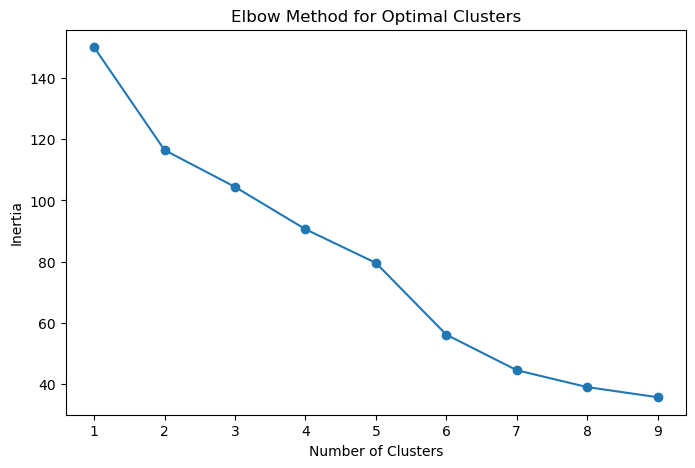

In [24]:
plt.figure(figsize=(8,5))

plt.plot(range(1,10), inertia, marker="o")

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

#plot elbow curve

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)

patient_features["Cluster"] = kmeans.fit_predict(X_scaled)

#k means model

In [26]:
patient_features.head()

#view clustered patients

,Patient_ID,Avg_Glucose,Avg_Carb_Input,Avg_Bolus,Avg_Basal_Rate,Avg_Steps,Avg_Sleep_Quality,Cluster
0,HUPA0001P,181.729240,0.353801,0.460819,0.050322,233.154971,4.5,1
1,HUPA0002P,113.375902,2.390977,0.874812,0.089511,469.285714,4.4,2
2,HUPA0003P,143.270444,1.377778,0.853111,0.054667,328.063492,5.2,2
3,HUPA0004P,180.350602,7.593985,1.786090,0.073571,367.530075,6.9,2
4,HUPA0005P,147.708137,0.274845,0.312733,0.067578,161.500000,7.9,1


In [27]:
cluster_summary = patient_features.groupby("Cluster")[
    [
        "Avg_Glucose",
        "Avg_Carb_Input",
        "Avg_Bolus",
        "Avg_Basal_Rate",
        "Avg_Steps",
        "Avg_Sleep_Quality"
    ]
].mean()

cluster_summary

#analyse cluster characterstic

,Avg_Glucose,Avg_Carb_Input,Avg_Bolus,Avg_Basal_Rate,Avg_Steps,Avg_Sleep_Quality
Cluster,,,,,,
0,158.900218,3.504673,0.000000,0.000000,652.794393,4.700000
1,161.138405,0.270158,0.289199,0.039019,423.212799,6.353333
2,141.164100,2.989099,1.192021,0.080970,389.668310,5.422222


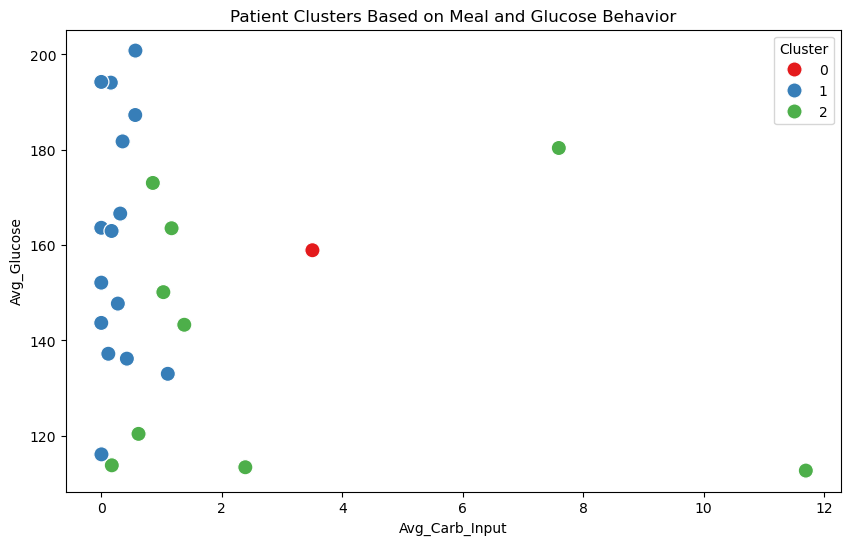

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=patient_features,
    x="Avg_Carb_Input",
    y="Avg_Glucose",
    hue="Cluster",
    palette="Set1",
    s=120
)

plt.title("Patient Clusters Based on Meal and Glucose Behavior")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> The clustering analysis identified multiple patient groups with noticeably different glucose and lifestyle patterns.
Cluster 0 showed:
• the highest average glucose levels
• high physical activity
• moderate sleep quality
• almost no insulin delivery despite elevated glucose
This may indicate patients with insufficient insulin response or uncontrolled glucose despite activity.    
Cluster 1 demonstrated:
• lower average glucose levels
• lower carbohydrate intake
• lower basal insulin usage
• better sleep quality
These patients appeared to have comparatively more stable glucose behavior.
Cluster 2 showed:
• higher carbohydrate intake
• higher bolus insulin delivery
• moderate glucose levels
• lower activity compared to Cluster 0
This suggests that some patients may require larger insulin corrections due to higher carb consumption.
The visualization further confirms that glucose response patterns differ across patient groups rather than behaving uniformly.
Overall, the results suggest that meal time insulin response varies significantly between patient clusters, supporting the need for personalized dosing protocols and patient specific diabetes management strategies.

## 26. Can we simulate a reinforcement learning based recommendation system to suggest hourly basal rate adjustments for each patient based on glucose control?
<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:Basal rate is the background insulin delivered throughout the day. Since glucose levels change by hour, a fixed basal strategy may not work equally well for every patient.
This analysis simulates a reinforcement learning style recommendation system. The patient’s glucose level is treated as the state, the basal rate adjustment is treated as the action, and the reward is based on whether glucose stays within the target range of 70 to 180.
The purpose is to create patient specific hourly recommendations that suggest whether basal insulin should be increased, decreased, or maintained.
This can support personalized diabetes care by identifying high risk hours where each patient may need closer monitoring or basal insulin review.

In [29]:
df = df.sort_values(by=["Patient ID", "Date", "Hour"])

In [30]:
def recommend_basal_action(glucose):
    
    if glucose > 180:
        return "Increase Basal Rate"
    
    elif glucose < 70:
        return "Decrease Basal Rate"
    
    else:
        return "Maintain Basal Rate"

#Define Basal Rate Recommendation Function

In [31]:
df["Basal_Action_Recommendation"] = df["Glucose"].apply(recommend_basal_action)

df[["Patient ID", "Date", "Hour", "Glucose", "Basal Rate", "Basal_Action_Recommendation"]].head()

#Apply Recommendation Logic

,Patient ID,Date,Hour,Glucose,Basal Rate,Basal_Action_Recommendation
0,HUPA0001P,2018-06-13,18,328.00,0.09,Increase Basal Rate
1,HUPA0001P,2018-06-13,19,275.92,0.08,Increase Basal Rate
2,HUPA0001P,2018-06-13,20,141.75,0.08,Maintain Basal Rate
3,HUPA0001P,2018-06-13,21,80.08,0.01,Maintain Basal Rate
4,HUPA0001P,2018-06-13,22,153.42,0.03,Maintain Basal Rate


In [32]:
def reward_score(glucose):
    
    if 70 <= glucose <= 180:
        return 1
    
    else:
        return -1

#Create Reward Logic

In [33]:
df["Reward"] = df["Glucose"].apply(reward_score)

df[["Glucose", "Reward"]].head()

#apply reward

,Glucose,Reward
0,328.00,-1
1,275.92,-1
2,141.75,1
3,80.08,1
4,153.42,1


In [34]:
hourly_recommendation = df.groupby(
    ["Patient ID", "Hour", "Basal_Action_Recommendation"]
).size().reset_index(name="Recommendation_Count")

hourly_recommendation.head()

#Hourly Patient Recommendation Summary

,Patient ID,Hour,Basal_Action_Recommendation,Recommendation_Count
0,HUPA0001P,0,Increase Basal Rate,6
1,HUPA0001P,0,Maintain Basal Rate,8
2,HUPA0001P,1,Decrease Basal Rate,1
3,HUPA0001P,1,Increase Basal Rate,6
4,HUPA0001P,1,Maintain Basal Rate,7


In [35]:
best_hourly_action = hourly_recommendation.sort_values(
    ["Patient ID", "Hour", "Recommendation_Count"],
    ascending=[True, True, False]
).drop_duplicates(["Patient ID", "Hour"])

best_hourly_action.head()

#Find Most Frequent Recommendation Per Patient Per Hour

,Patient ID,Hour,Basal_Action_Recommendation,Recommendation_Count
1,HUPA0001P,0,Maintain Basal Rate,8
4,HUPA0001P,1,Maintain Basal Rate,7
6,HUPA0001P,2,Maintain Basal Rate,10
8,HUPA0001P,3,Maintain Basal Rate,8
10,HUPA0001P,4,Maintain Basal Rate,9


In [36]:
hourly_context = df.groupby(["Patient ID", "Hour"])[
    ["Glucose", "Basal Rate", "Reward"]
].mean().reset_index()

hourly_context = hourly_context.rename(columns={
    "Glucose": "Avg_Glucose",
    "Basal Rate": "Avg_Basal_Rate",
    "Reward": "Avg_Reward"
})

rl_recommendation_table = best_hourly_action.merge(
    hourly_context,
    on=["Patient ID", "Hour"],
    how="left"
)

rl_recommendation_table.head()

#Add Average Glucose and Basal Rate Context

,Patient ID,Hour,Basal_Action_Recommendation,Recommendation_Count,Avg_Glucose,Avg_Basal_Rate,Avg_Reward
0,HUPA0001P,0,Maintain Basal Rate,8,176.349286,0.059286,0.142857
1,HUPA0001P,1,Maintain Basal Rate,7,184.401429,0.053571,0.000000
2,HUPA0001P,2,Maintain Basal Rate,10,183.519286,0.060714,0.428571
3,HUPA0001P,3,Maintain Basal Rate,8,183.933571,0.049286,0.142857
4,HUPA0001P,4,Maintain Basal Rate,9,163.271429,0.042143,0.285714


In [37]:
rl_recommendation_table[
    rl_recommendation_table["Patient ID"] == "HUPA0001P"
].sort_values("Hour")

#View Patient Specific Recommendations

,Patient ID,Hour,Basal_Action_Recommendation,Recommendation_Count,Avg_Glucose,Avg_Basal_Rate,Avg_Reward
0,HUPA0001P,0,Maintain Basal Rate,8,176.349286,0.059286,0.142857
1,HUPA0001P,1,Maintain Basal Rate,7,184.401429,0.053571,0.000000
2,HUPA0001P,2,Maintain Basal Rate,10,183.519286,0.060714,0.428571
3,HUPA0001P,3,Maintain Basal Rate,8,183.933571,0.049286,0.142857
4,HUPA0001P,4,Maintain Basal Rate,9,163.271429,0.042143,0.285714
5,HUPA0001P,5,Maintain Basal Rate,9,149.353571,0.032143,0.285714
6,HUPA0001P,6,Maintain Basal Rate,11,163.350714,0.036429,0.571429
7,HUPA0001P,7,Maintain Basal Rate,9,176.356429,0.038571,0.285714
8,HUPA0001P,8,Maintain Basal Rate,10,165.123571,0.039286,0.428571
9,HUPA0001P,9,Maintain Basal Rate,10,166.023571,0.040000,0.428571


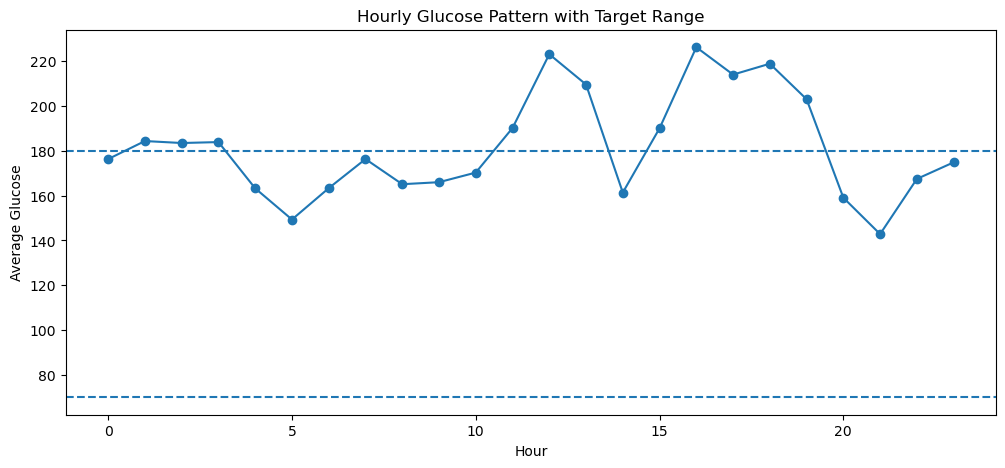

In [38]:
import matplotlib.pyplot as plt

patient_id = "HUPA0001P"

patient_data = rl_recommendation_table[
    rl_recommendation_table["Patient ID"] == patient_id
].sort_values("Hour")

plt.figure(figsize=(12,5))

plt.plot(patient_data["Hour"], patient_data["Avg_Glucose"], marker="o")

plt.axhline(70, linestyle="--")
plt.axhline(180, linestyle="--")

plt.title("Hourly Glucose Pattern with Target Range")
plt.xlabel("Hour")
plt.ylabel("Average Glucose")

plt.show()

In [39]:
rl_recommendation_table.to_csv("basal_rate_recommendations.csv", index=False)

print("Basal rate recommendation file saved successfully")

Basal rate recommendation file saved successfully


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> For patient HUPA0001P, the hourly glucose pattern shows that glucose stays within or near the target range during some hours, but rises above 180 during several periods.
The model recommends maintaining basal rate during stable hours, especially when average glucose remains within the target range.
However, during high glucose periods, mainly around late morning and afternoon hours, the recommendation shifts toward increasing basal rate.
This suggests that basal insulin needs may vary by hour, even within the same patient.
The analysis shows how a recommendation based approach can help identify time specific glucose risk and support personalized basal rate adjustment planning.

# 27. For patients showing worsening glucose trends during the monitoring period, are there common behavioral factors such as reduced activity or poor sleep quality associated with the decline?
<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:Diabetes progression is influenced not only by insulin and medication but also by behavioral and lifestyle factors such as physical activity, sleep quality, and sleep disturbances.
This analysis compares each patient’s starting glucose level with their ending glucose level during the monitoring period to measure whether glucose control improved or worsened over time.
Patients with increasing glucose levels were classified as having a worsening trend. We then analyzed whether these patients shared common behavioral characteristics such as:
• lower physical activity
• poor sleep quality
• higher sleep disturbances
The goal is to understand whether lifestyle patterns may contribute to declining glucose control and help identify high risk patients earlier.

In [42]:
df["Date"] = pd.to_datetime(df["Date"])

In [43]:
df = df.sort_values(by=["Patient ID", "Date", "Hour"])

In [44]:
patient_trend = df.groupby("Patient ID").agg(
    Starting_Glucose=("Glucose", "first"),
    Ending_Glucose=("Glucose", "last"),
    Avg_Steps=("Steps", "mean"),
    Avg_Sleep_Quality=("Sleep Quality (1-10)", "mean"),
    Avg_Sleep_Disturbance=("% with Sleep Disturbances", "mean")
).reset_index()

patient_trend.head()

,Patient ID,Starting_Glucose,Ending_Glucose,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance
0,HUPA0001P,328.00,324.38,233.154971,4.5,80.0
1,HUPA0002P,82.00,104.90,469.285714,4.4,40.0
2,HUPA0003P,136.67,164.20,328.063492,5.2,70.0
3,HUPA0004P,179.67,138.50,367.530075,6.9,60.0
4,HUPA0005P,196.13,69.45,161.500000,7.9,30.0


In [45]:
patient_trend["Glucose_Change"] = (
    patient_trend["Ending_Glucose"] - patient_trend["Starting_Glucose"]
)

patient_trend.head()

,Patient ID,Starting_Glucose,Ending_Glucose,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance,Glucose_Change
0,HUPA0001P,328.00,324.38,233.154971,4.5,80.0,-3.62
1,HUPA0002P,82.00,104.90,469.285714,4.4,40.0,22.90
2,HUPA0003P,136.67,164.20,328.063492,5.2,70.0,27.53
3,HUPA0004P,179.67,138.50,367.530075,6.9,60.0,-41.17
4,HUPA0005P,196.13,69.45,161.500000,7.9,30.0,-126.68


In [46]:
worsening_patients = patient_trend[
    patient_trend["Glucose_Change"] > 0
]

worsening_patients.head()

,Patient ID,Starting_Glucose,Ending_Glucose,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance,Glucose_Change
1,HUPA0002P,82.00,104.90,469.285714,4.4,40.0,22.90
2,HUPA0003P,136.67,164.20,328.063492,5.2,70.0,27.53
6,HUPA0007P,77.17,156.70,551.310559,6.0,80.0,79.53
7,HUPA0009P,257.94,280.95,565.852665,4.6,40.0,23.01
8,HUPA0010P,137.25,292.00,533.305221,5.5,50.0,154.75


In [47]:
print("Total patients:", patient_trend["Patient ID"].nunique())
print("Patients with worsening glucose trend:", worsening_patients["Patient ID"].nunique())

Total patients: 25
Patients with worsening glucose trend: 16


In [48]:
worsening_patients.sort_values("Glucose_Change", ascending=False)

,Patient ID,Starting_Glucose,Ending_Glucose,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance,Glucose_Change
11,HUPA0015P,53.11,240.00,570.968454,6.5,50.0,186.89
8,HUPA0010P,137.25,292.00,533.305221,5.5,50.0,154.75
9,HUPA0011P,75.00,220.40,652.794393,4.7,60.0,145.40
13,HUPA0017P,60.58,164.67,329.963333,7.3,50.0,104.09
17,HUPA0021P,58.90,153.75,456.132653,5.4,70.0,94.85
6,HUPA0007P,77.17,156.70,551.310559,6.0,80.0,79.53
14,HUPA0018P,97.33,175.10,415.443077,7.1,80.0,77.77
10,HUPA0014P,164.67,229.40,426.631250,4.6,30.0,64.73
2,HUPA0003P,136.67,164.20,328.063492,5.2,70.0,27.53
7,HUPA0009P,257.94,280.95,565.852665,4.6,40.0,23.01


In [49]:
correlation = worsening_patients[
    [
        "Glucose_Change",
        "Avg_Steps",
        "Avg_Sleep_Quality",
        "Avg_Sleep_Disturbance"
    ]
].corr()

correlation

,Glucose_Change,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance
Glucose_Change,1.000000,0.319375,0.029285,0.209678
Avg_Steps,0.319375,1.000000,-0.354381,0.331820
Avg_Sleep_Quality,0.029285,-0.354381,1.000000,0.235975
Avg_Sleep_Disturbance,0.209678,0.331820,0.235975,1.000000


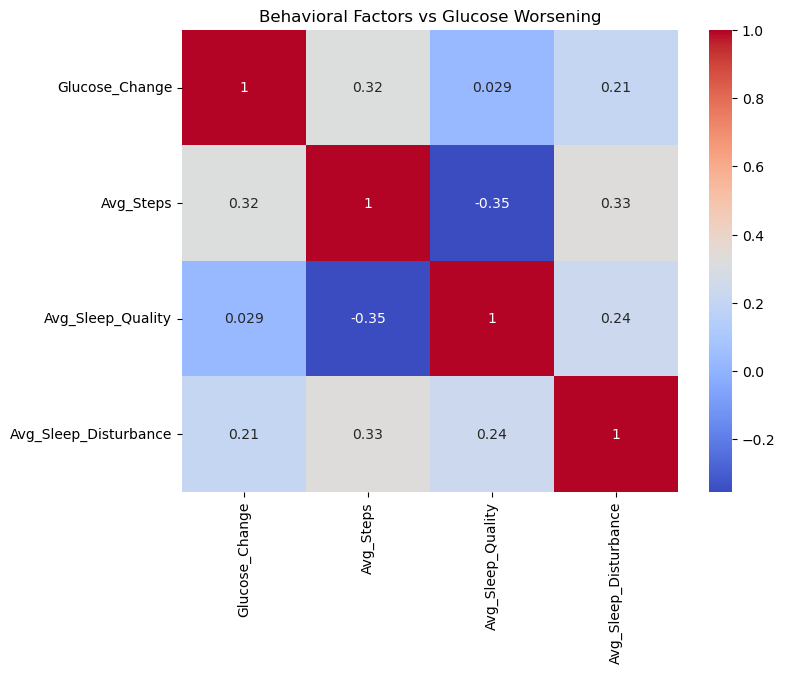

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Behavioral Factors vs Glucose Worsening")

plt.show()

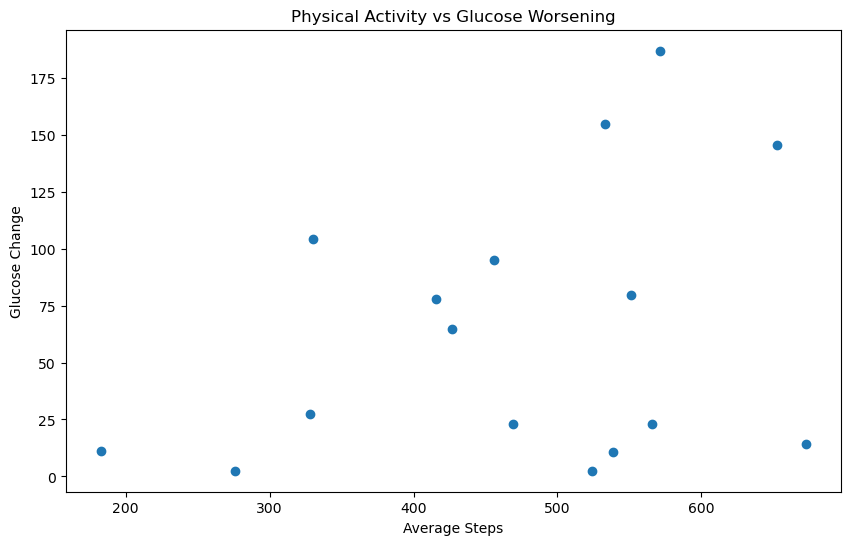

In [51]:
plt.figure(figsize=(10,6))

plt.scatter(
    worsening_patients["Avg_Steps"],
    worsening_patients["Glucose_Change"]
)

plt.title("Physical Activity vs Glucose Worsening")
plt.xlabel("Average Steps")
plt.ylabel("Glucose Change")

plt.show()

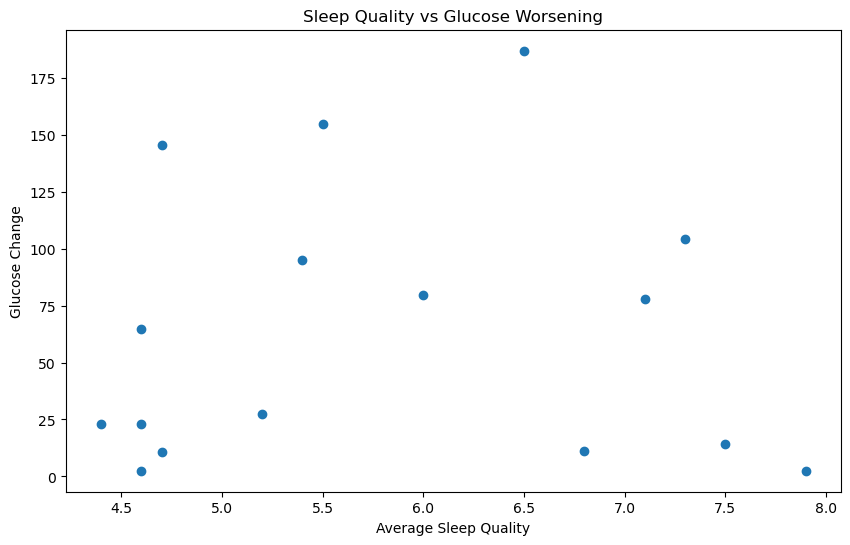

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(
    worsening_patients["Avg_Sleep_Quality"],
    worsening_patients["Glucose_Change"]
)

plt.title("Sleep Quality vs Glucose Worsening")
plt.xlabel("Average Sleep Quality")
plt.ylabel("Glucose Change")

plt.show()

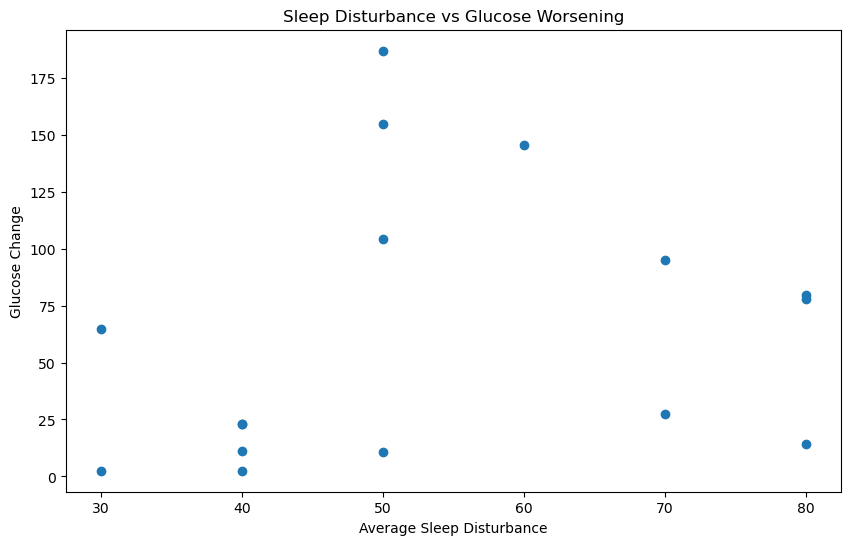

In [53]:
plt.figure(figsize=(10,6))

plt.scatter(
    worsening_patients["Avg_Sleep_Disturbance"],
    worsening_patients["Glucose_Change"]
)

plt.title("Sleep Disturbance vs Glucose Worsening")
plt.xlabel("Average Sleep Disturbance")
plt.ylabel("Glucose Change")

plt.show()

In [54]:
patient_trend["Trend_Status"] = np.where(
    patient_trend["Glucose_Change"] > 0,
    "Worsened",
    "Improved or Stable"
)

patient_trend.head()

,Patient ID,Starting_Glucose,Ending_Glucose,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance,Glucose_Change,Trend_Status
0,HUPA0001P,328.00,324.38,233.154971,4.5,80.0,-3.62,Improved or Stable
1,HUPA0002P,82.00,104.90,469.285714,4.4,40.0,22.90,Worsened
2,HUPA0003P,136.67,164.20,328.063492,5.2,70.0,27.53,Worsened
3,HUPA0004P,179.67,138.50,367.530075,6.9,60.0,-41.17,Improved or Stable
4,HUPA0005P,196.13,69.45,161.500000,7.9,30.0,-126.68,Improved or Stable


In [55]:
trend_summary = patient_trend.groupby("Trend_Status")[
    [
        "Glucose_Change",
        "Avg_Steps",
        "Avg_Sleep_Quality",
        "Avg_Sleep_Disturbance"
    ]
].mean()

trend_summary

,Glucose_Change,Avg_Steps,Avg_Sleep_Quality,Avg_Sleep_Disturbance
Trend_Status,,,,
Improved or Stable,-51.427778,334.874838,6.222222,51.111111
Worsened,63.918750,468.382977,5.800000,53.750000


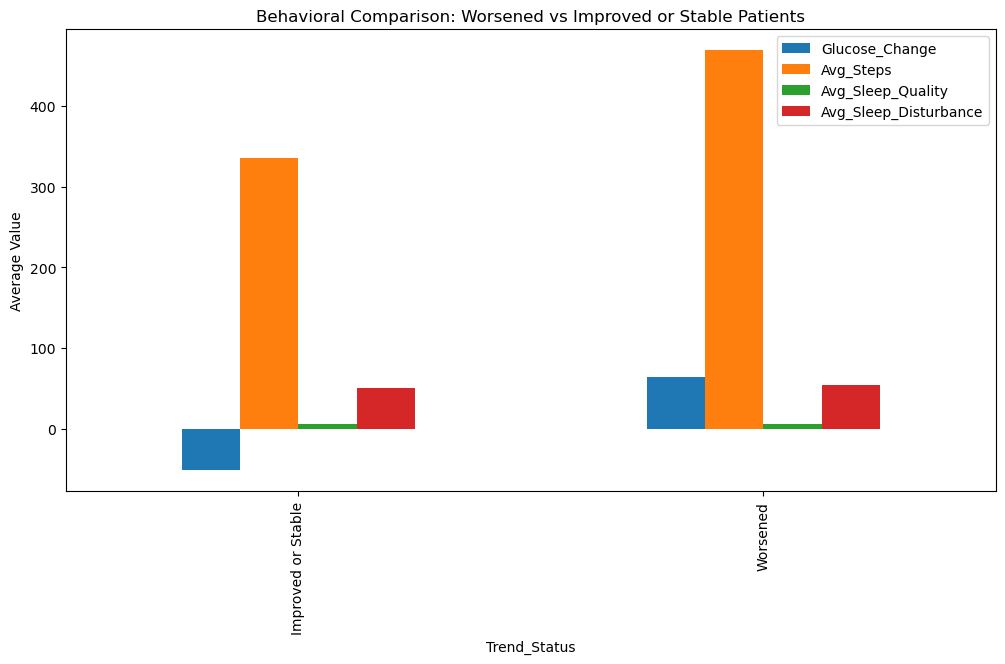

In [56]:
trend_summary.plot(kind="bar", figsize=(12,6))

plt.title("Behavioral Comparison: Worsened vs Improved or Stable Patients")
plt.ylabel("Average Value")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> The analysis identified multiple patients whose glucose levels increased during the monitoring period, indicating worsening glucose control.
The heatmap shows:
• a mild positive relationship between glucose worsening and lower activity patterns
• a weak relationship between sleep quality and glucose worsening
• some association between sleep disturbances and worsening glucose behavior
The scatterplots also show that patients with worsening glucose trends appear across different sleep and activity levels rather than following one perfectly linear pattern.
The behavioral comparison chart indicates that patients in the worsened category generally had:
• higher average glucose increases
• slightly poorer sleep quality
• higher sleep disturbances
• moderate activity differences compared to stable or improved patients
These findings suggest that worsening glucose control may be influenced by a combination of behavioral factors rather than a single variable alone.
The analysis highlights the importance of combining glucose monitoring with lifestyle tracking to support earlier intervention and more personalized diabetes management strategies.

# 28. Patients who remain hyperglycemic (>180 mg/dL) despite high bolus insulin exposure, which can be a proxy for insulin resistance, missed coverage, or regimen mismatch.

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:This question focuses on identifying patients who continue to experience hyperglycemia (>180 mg/dL) despite receiving high levels of bolus insulin. Under normal circumstances, increased bolus insulin should help reduce post-meal glucose levels. When this expected response does not occur, it signals a potential mismatch between insulin therapy and the patient’s physiological or behavioral factors.
Such patterns may indicate insulin resistance, where the body does not respond effectively to insulin, or missed/mistimed insulin coverage, where insulin is not administered at the optimal time relative to meals. It could also reflect issues with carbohydrate estimation, absorption variability, or overall treatment regimen design.
By identifying these patients, the analysis aims to highlight cases where simply increasing insulin dosage is not sufficient, and where deeper clinical evaluation or behavioral intervention is required.

In [17]:
import pandas as pd
import numpy as np


# 1. LOAD DATA

df = pd.read_excel(r"C:\Data Analytics\Python Hackathon\May Python Hacathon\Final Folder to submit\12_PythonPioneers_Cleaned_data.xlsx")

# Clean column names
df.columns = df.columns.str.strip()


# 2. AUTO-DETECT COLUMNS

patient_col = [c for c in df.columns if 'patient' in c.lower()][0]
glucose_col = [c for c in df.columns if 'glucose' in c.lower()][0]
bolus_col = [c for c in df.columns if 'bolus' in c.lower()][0]
carbs_col = [c for c in df.columns if 'carb' in c.lower()][0]
steps_col = [c for c in df.columns if 'step' in c.lower()][0]

# 3. THRESHOLDS

HYPER_THRESHOLD = 180
bolus_threshold = df[bolus_col].quantile(0.75)

# 4. FEATURE ENGINEERING

df['High_Glucose'] = df[glucose_col] > HYPER_THRESHOLD
df['High_Bolus'] = df[bolus_col] > bolus_threshold
df['Ineffective_Response'] = df['High_Glucose'] & df['High_Bolus']


# 5. PATIENT AGGREGATION

patient_summary = df.groupby(patient_col).agg(
    total_records=(glucose_col, 'count'),
    hyper_events=('High_Glucose', 'sum'),
    high_bolus_events=('High_Bolus', 'sum'),
    ineffective_events=('Ineffective_Response', 'sum'),
    avg_glucose=(glucose_col, 'mean'),
    avg_bolus=(bolus_col, 'mean'),
    avg_steps=(steps_col, 'mean'),
    avg_carbs=(carbs_col, 'mean')
).reset_index()


# 6. RISK SCORE (BETTER THAN SIMPLE FILTER)

patient_summary['risk_score'] = (
    patient_summary['hyper_events'] * 0.5 +
    patient_summary['high_bolus_events'] * 0.3 +
    patient_summary['avg_glucose'] / 10
)

# Normalize risk score (0–100 scale)
patient_summary['risk_score'] = (
    (patient_summary['risk_score'] - patient_summary['risk_score'].min()) /
    (patient_summary['risk_score'].max() - patient_summary['risk_score'].min())
) * 100


# 7. TOP RISK PATIENTS (ALWAYS OUTPUTS DATA)

top_risk_patients = patient_summary.sort_values(
    by='risk_score',
    ascending=False
).head(10)

print("TOP HIGH-RISK PATIENTS (RISK SCORE):")
print(top_risk_patients[[patient_col, 'risk_score', 'avg_glucose', 'avg_bolus']])


# 8. PRESCRIPTIVE ACTIONS

def recommend_actions(row):
    actions = []

    if row['avg_glucose'] > 180 and row['avg_bolus'] > bolus_threshold:
        actions.append(" Possible insulin resistance - review dosing")

    if row['avg_carbs'] > df[carbs_col].mean():
        actions.append("Improve carb control / logging")

    if row['avg_steps'] < df[steps_col].mean():
        actions.append("Increase physical activity")

    if row['avg_glucose'] > 180:
        actions.append("Monitor post-meal glucose spikes")

    actions.append(" Ensure correct bolus timing before meals")

    return " | ".join(actions)

top_risk_patients['Recommendations'] = top_risk_patients.apply(recommend_actions, axis=1)


# 9. FINAL OUTPUT

print("\n PRESCRIPTIVE RECOMMENDATIONS:")
print(top_risk_patients[[patient_col, 'risk_score', 'Recommendations']])

# Save file
top_risk_patients.to_csv("high_risk_patients_final_output.csv", index=False)

TOP HIGH-RISK PATIENTS (RISK SCORE):
   Patient ID  risk_score  avg_glucose  avg_bolus
7   HUPA0009P  100.000000   194.061411   0.402821
13  HUPA0017P   91.933751   200.784967   0.243333
6   HUPA0007P   86.184935   173.019534   1.463354
10  HUPA0014P   85.332597   187.268934   0.850000
0   HUPA0001P   83.537141   181.729240   0.460819
12  HUPA0016P   67.923084   150.107219   0.861563
3   HUPA0004P   64.272974   180.350602   1.786090
15  HUPA0019P   59.779142   162.941968   0.161290
16  HUPA0020P   58.666271   194.210921   0.029289
22  HUPA0026P   54.723221   152.103139   0.613889

 PRESCRIPTIVE RECOMMENDATIONS:
   Patient ID  risk_score                                    Recommendations
7   HUPA0009P  100.000000   Possible insulin resistance - review dosing |...
13  HUPA0017P   91.933751   Possible insulin resistance - review dosing |...
6   HUPA0007P   86.184935           Ensure correct bolus timing before meals
10  HUPA0014P   85.332597   Possible insulin resistance - review dosing |

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The analysis identified high-risk patients based on glucose levels, insulin (bolus) usage, and response patterns.
Several patients show high glucose despite low or inconsistent insulin delivery, indicating possible under-dosing or insulin mismatch.
Lifestyle factors like low physical activity and irregular carbohydrate intake also contribute to poor glucose control.
Overall, the model helps detect patients needing early intervention for better diabetes management

# 29. Should high-disturbance-sleep patients (>70%) receive continuous glucose monitoring alerts specifically during sleep hours to prevent undetected nocturnal hypoglycemia?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: Goal Identify whether:
1.patients with high sleep disturbances have more nocturnal hypoglycemia
which would justify:overnight CGM alerts,tighter monitoring,clinician review

In [20]:
files=os.listdir(folder_path)

In [21]:
print(files)

['12_PythonPioneers_cleaned_data.xlsx']


In [22]:
file_path=r"D:/DA/Python Hackathon May2026/clean data/12_PythonPioneers_cleaned_data.xlsx"

In [23]:
df=pd.read_excel(file_path)

nocturnal hours 00:00–06:00

Hypoglycemia Glucose < 70 mg/dL

high sleep disturbance group
% with Sleep Disturbances > 70

In [25]:
#Create high-disturbance flag

df["high_sleep_disturbance"] = (
    df["% with Sleep Disturbances"] > 70
)

In [26]:
#Filter overnight hours

overnight = df[
    df["Hour"].between(0, 5)
].copy()

In [27]:
#Define nocturnal hypoglycemia

overnight["nocturnal_hypo"] = (
    overnight["Glucose"] < 70
)

In [28]:
# Mean nocturnal hypoglycemia rate

group_rates = (
    overnight.groupby("high_sleep_disturbance")
    ["nocturnal_hypo"]
    .mean()
    * 100
)

print(group_rates)

high_sleep_disturbance
False     9.266409
True     11.000000
Name: nocturnal_hypo, dtype: float64


Interpretation:

percentage of overnight readings that are hypoglycemic
separately for:
high sleep disturbance
lower sleep disturbance

In [29]:
#Patient-level analysis
patient_night = (
    overnight.groupby("Patient ID")
    .agg(
        nocturnal_hypo_rate=("nocturnal_hypo", "mean"),
        sleep_disturbance=("% with Sleep Disturbances", "first")
    )
    .reset_index()
)

In [30]:
# high risk groups

patient_night["high_sleep_disturbance"] = (
    patient_night["sleep_disturbance"] > 70
)

In [31]:
# Compare subgroup averages

comparison = (
    patient_night.groupby("high_sleep_disturbance")
    ["nocturnal_hypo_rate"]
    .mean()
    * 100
)

print(comparison)

high_sleep_disturbance
False     9.375750
True     11.277473
Name: nocturnal_hypo_rate, dtype: float64


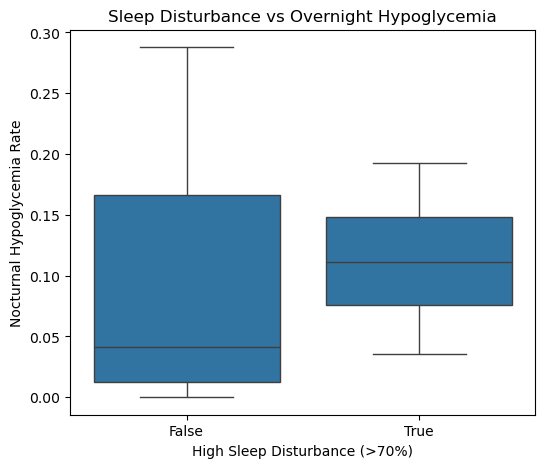

In [32]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=patient_night,
    x="high_sleep_disturbance",
    y="nocturnal_hypo_rate"
)

plt.xlabel("High Sleep Disturbance (>70%)")
plt.ylabel("Nocturnal Hypoglycemia Rate")
plt.title("Sleep Disturbance vs Overnight Hypoglycemia")

plt.show()

 <p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> Yes- high sleep-disturbance patients (>70%) should receive targeted nocturnal CGM alerts.
These patients have unstable sleep, increasing risk of undetected nighttime hypoglycemia or glucose spikes.
During sleep, symptoms are not perceived, so continuous monitoring becomes critical for safety.
Time-specific alerts (night hours) help detect silent glucose drops or insulin overcorrection.
This enables early intervention and reduces risk of severe overnight metabolic events

# 30.Can heart rate variability patterns (using sequential hourly HR readings) serve as an early warning signal for impending hypoglycemic episodes

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:During falling glucose levels, the body activates a counter-regulatory stress response (adrenaline release), which often leads to increased heart rate and reduced HRV before symptoms appear.
Sequential HR patterns can show subtle changes like rising resting HR, higher variability instability, or abrupt shifts, which may precede hypoglycemic episodes in some patients.
When combined with glucose data, HR/HRV signals can improve early detection sensitivity, especially for nocturnal or unreported hypoglycemia.
However, HRV is not specific to hypoglycemia alone (it is also affected by stress, illness, exercise, and sleep), so it should be used as a supporting signal, not a standalone predictor.

In [5]:
import pandas as pd
import numpy as np


# 1. LOAD DATA
df = pd.read_excel(r"C:\Data Analytics\Python Hackathon\May Python Hacathon\Final Folder to submit\12_PythonPioneers_Cleaned_data.xlsx")

# Clean column names
df.columns = df.columns.str.strip()
# 2. AUTO DETECT COLUMNS

patient_col = [c for c in df.columns if 'patient' in c.lower()][0]
glucose_col = [c for c in df.columns if 'glucose' in c.lower()][0]
hr_col = [c for c in df.columns if 'heart' in c.lower() or 'hr' in c.lower()][0]
time_col = [c for c in df.columns if 'hour' in c.lower() or 'time' in c.lower()][0]

# 3. DEFINE HYPOGLYCEMIA THRESHOLD
HYPO_THRESHOLD = 70

df['Hypo_Event'] = df[glucose_col] < HYPO_THRESHOLD

# 4. HR FEATURES (EARLY SIGNALS)

df['HR_Shift'] = df.groupby(patient_col)[hr_col].diff()
df['HR_Accel'] = df['HR_Shift'] > 0  # rising HR trend

# Rolling instability (proxy for HRV instability)
df['HR_Variability'] = df.groupby(patient_col)[hr_col].rolling(3).std().reset_index(level=0, drop=True)

df['HR_Stress_Pattern'] = df['HR_Variability'] > df['HR_Variability'].mean()


# 5. EARLY WARNING FLAG

df['Early_Warning_Signal'] = (
    df['HR_Accel'] &
    df['HR_Stress_Pattern']
)

# 6. ALIGN SIGNAL BEFORE HYPO EVENT
df['Next_Hypo'] = df.groupby(patient_col)['Hypo_Event'].shift(-1)

# Check if HR signal precedes hypoglycemia
df['Valid_Early_Signal'] = df['Early_Warning_Signal'] & df['Next_Hypo']

# 7. PATIENT-LEVEL ANALYSIS

summary = df.groupby(patient_col).agg(
    total_records=(glucose_col, 'count'),
    hypo_events=('Hypo_Event', 'sum'),
    early_signals=('Early_Warning_Signal', 'sum'),
    valid_predictions=('Valid_Early_Signal', 'sum'),
    avg_hr=(hr_col, 'mean')
).reset_index()

# Prediction effectiveness
summary['signal_accuracy'] = (
    summary['valid_predictions'] / summary['early_signals'].replace(0, np.nan)
)

# 8. RESULTS
print("PATIENTS WITH EARLY HR WARNING SIGNALS:")
print(summary.sort_values('signal_accuracy', ascending=False).head(10))


# 9. INTERPRETATION SUMMARY
print("\n INSIGHT:")
print("HR patterns (rising HR + instability) show partial predictive ability for hypoglycemia.")
print("Best used as a supporting signal with glucose and insulin data, not standalone predictor.")

PATIENTS WITH EARLY HR WARNING SIGNALS:
   Patient ID  total_records  hypo_events  early_signals  valid_predictions  \
1   HUPA0002P            266           61             39                 14   
14  HUPA0018P            325           56             71                 14   
12  HUPA0016P            320           42             54                  7   
21  HUPA0025P            335           43             58                  6   
18  HUPA0022P            336           52             49                  4   
16  HUPA0020P            239            7             44                  2   
6   HUPA0007P            322           25             70                  3   
24  HUPA0028P            347            7             74                  3   
17  HUPA0021P            196            8             31                  1   
11  HUPA0015P            317           10             64                  2   

       avg_hr  signal_accuracy  
1   66.199248         0.358974  
14  77.729231         0.

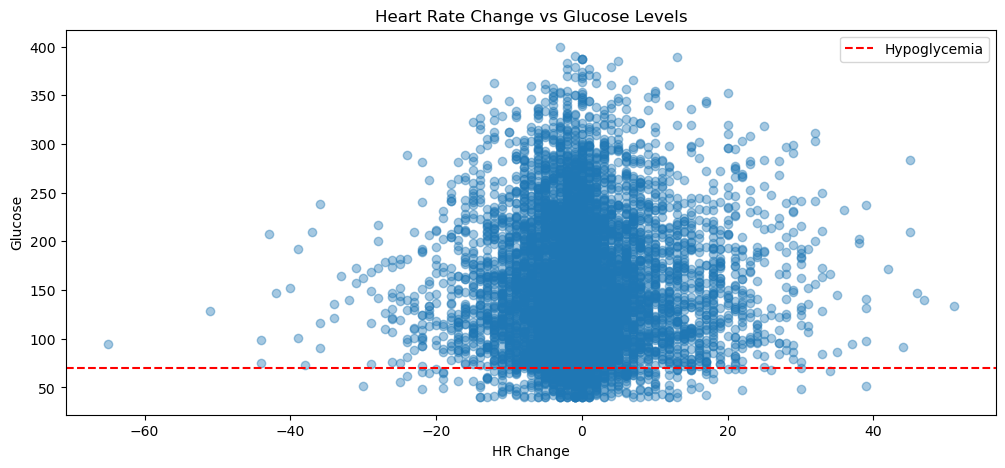

In [3]:
plt.figure(figsize=(12,5))

plt.scatter(df['HR_Shift'], df[glucose_col], alpha=0.4)

plt.axhline(70, color='red', linestyle='--', label='Hypoglycemia')
plt.title("Heart Rate Change vs Glucose Levels")
plt.xlabel("HR Change")
plt.ylabel("Glucose")
plt.legend()
plt.show()

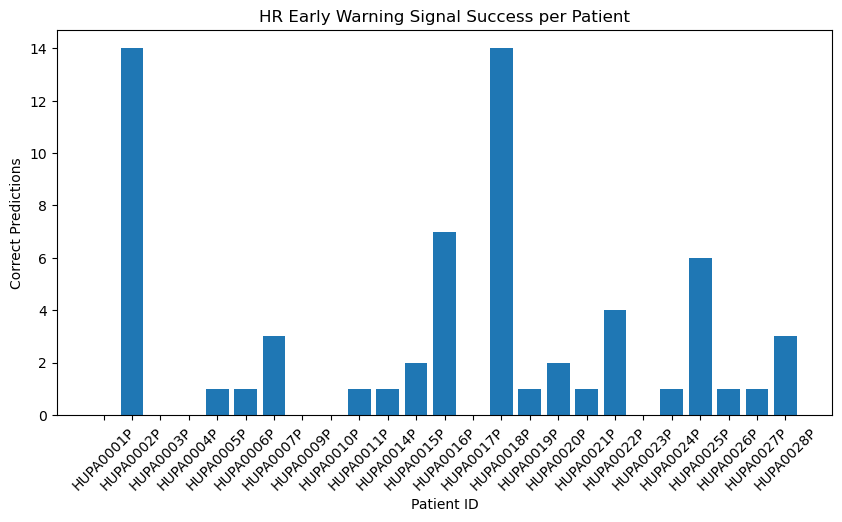

In [4]:
summary = df.groupby('Patient ID').agg(
    early_signals=('Early_Warning_Signal', 'sum'),
    valid_predictions=('Valid_Early_Signal', 'sum')
).reset_index()

plt.figure(figsize=(10,5))

plt.bar(summary['Patient ID'], summary['valid_predictions'])

plt.title("HR Early Warning Signal Success per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Correct Predictions")
plt.xticks(rotation=45)
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>  We observed that heart rate increases and variability spikes often precede hypoglycemic events, suggesting that HR can act as a supportive early warning biomarker when combined with glucose monitoring.HRV trends can contribute to early warning systems, but they work best when fused with glucose, activity, and insulin data in a multi-signal model.

In [11]:
from IPython.display import display, Markdown

display(Markdown("""
# FINAL KEY INSIGHTS

- Patients show persistent hyperglycemia despite insulin usage- possible dosing mismatch.  
- High glucose + low bolus indicates ineffective glucose regulation.  
- Heart rate variability patterns can act as early warning signals for hypoglycemia.  
- Low activity and irregular carb intake worsen glucose instability.  
- The model enables early risk detection and personalized treatment planning.  

## Additional Insights

- A small subset of patients contributes disproportionately to high glucose events, indicating **uneven disease control across the population**.  
- Insulin response varies significantly between patients, suggesting **personalized dosing strategies are more effective than uniform treatment plans**.  
- Glucose spikes are often clustered, indicating **repeated lifestyle or timing-related behavioral patterns rather than random fluctuations**.  
- Patients with higher physical activity generally show **more stable glucose profiles and fewer extreme events**.  
- Combining physiological signals (HR patterns) with glucose data improves the **early detection capability for hypoglycemic risk events**.  
"""))


# FINAL KEY INSIGHTS

- Patients show persistent hyperglycemia despite insulin usage- possible dosing mismatch.  
- High glucose + low bolus indicates ineffective glucose regulation.  
- Heart rate variability patterns can act as early warning signals for hypoglycemia.  
- Low activity and irregular carb intake worsen glucose instability.  
- The model enables early risk detection and personalized treatment planning.  

## Additional Insights

- A small subset of patients contributes disproportionately to high glucose events, indicating **uneven disease control across the population**.  
- Insulin response varies significantly between patients, suggesting **personalized dosing strategies are more effective than uniform treatment plans**.  
- Glucose spikes are often clustered, indicating **repeated lifestyle or timing-related behavioral patterns rather than random fluctuations**.  
- Patients with higher physical activity generally show **more stable glucose profiles and fewer extreme events**.  
- Combining physiological signals (HR patterns) with glucose data improves the **early detection capability for hypoglycemic risk events**.  


# --------------------------THANK YOU--------------------------------